In [50]:
import importlib
import numpy as np
import tensorflow as tf
import torch
import pandas as pd
from nbformat.v1 import upgrade
from tqdm import tqdm
import yfinance as yf
import xlsxwriter
import random
import matplotlib.pyplot as plt
import pickle

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv

# import yahoo_fin as yhf # This module seems to be broken

In [2]:
print(tf.__version__)

2.21.0


# **1. Building our Portfolio Management Environment**

## **1.1. Data Preprocessing & Stock Picking**

In [ ]:
# Extract the S&P500 tickers
# The table format of the Wikipedia list is the easiest for ectraction, since the list from Bloomberg include suffixes
# Wikipedia list was cross checked against the Bloomberg list and they match

import requests
# Debug comment: Chrome (Standard): Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36

headers1 = {
    "User-Agent":"Mozilla/5.0"
}

url1 = "https://www.tradingview.com/symbols/SPX/components/"
r1 = requests.get(url1, headers=headers1)
r1.status_code

url2 = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
r2 = requests.get(url2, headers=headers1)
r2.status_code


'''url3 = "https://www.slickcharts.com/sp500"
r3 = requests.get(url3, headers=headers1)
r3.status_code'''

'url3 = "https://www.slickcharts.com/sp500"\nr3 = requests.get(url3, headers=headers1)\nr3.status_code'

In [ ]:
# Read the S&P500 list on Wikipedia
spxTicks = pd.read_html(
    r2.text
)

C:\Users\anask\AppData\Local\Temp\ipykernel_27992\1912178706.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  spxTicks = pd.read_html(


In [ ]:
# Build a PD Dataframe of the Tickers symbol & Industry Sector
# The industry sector is tracked to ensure that our pick includes assets from 7 different sectors
spxTicks_symb = pd.DataFrame(spxTicks[0]['Symbol'])
spxTicks_sec = pd.DataFrame(spxTicks[0]['GICS Sector'])
#display(spxTicks_symb)
#display(spxTicks_sec)
spxTicks_conc = pd.concat([spxTicks_symb,spxTicks_sec],axis=1)
spxTicks_conc = spxTicks_conc.rename(columns = {'GICS Sector':'Sector'})
spxTicks_conc

,Symbol,Sector
0,MMM,Industrials
1,AOS,Industrials
2,ABT,Health Care
3,ABBV,Health Care
4,ACN,Information Technology
...,...,...
498,XYL,Industrials
499,YUM,Consumer Discretionary
500,ZBRA,Information Technology
501,ZBH,Health Care


<span style = "color:orange">**Do not run the excel writer everytime.**</span>

In [51]:
'''writer1 = pd.ExcelWriter('spxTicksInds.xlsx', engine='xlsxwriter')
spxTicks_conc.to_excel(writer1)
writer1.close()'''

"writer1 = pd.ExcelWriter('spxTicksInds.xlsx', engine='xlsxwriter')\nspxTicks_conc.to_excel(writer1)\nwriter1.close()"

### **1.1.1. Random Stocks Pick (1st model)**

In [ ]:
# Group the tickers into separate lists by sector
# The 7 sectors of interest for this project are Consumer Discretionary, Communication Services,
# Energy, Financials, Health Care, Industrials, and Information Technology

consumerDisc = [] # Consumer Discretionary
communications = [] # Commmunication Services
energy = [] # Energy
financialSvc = [] # Financials
healthcare = [] # Health Care
industrials = [] # Industrials
technology = [] # Information Technology
otherStocks = [] # Any other

n1 = (spxTicks_conc).shape[0]
tk1 = spxTicks_conc.copy()

for i in range(0,n1):
    print(i,tk1.loc[i]['Symbol'], tk1.loc[i]['Sector'])
    #tk1.append(yf.Ticker("tk")) # Declare ticker
    if len(tk1.loc[i]['Sector'])!=0:
        if tk1.loc[i]['Sector'] == "Consumer Discretionary":
            consumerDisc.append(tk1.loc[i]['Symbol'])
        elif tk1.loc[i]['Sector'] == "Communication Services":
            communications.append(tk1.loc[i]['Symbol'])
        elif tk1.loc[i]['Sector'] == "Energy":
            energy.append(tk1.loc[i]['Symbol'])
        elif tk1.loc[i]['Sector'] == "Financials":
            financialSvc.append(tk1.loc[i]['Symbol'])
        elif tk1.loc[i]['Sector'] == "Health Care":
            healthcare.append(tk1.loc[i]['Symbol'])
        elif tk1.loc[i]['Sector'] == "Industrials":
            industrials.append(tk1.loc[i]['Symbol'])
        elif tk1.loc[i]['Sector'] == "Information Technology":
            technology.append(tk1.loc[i]['Symbol'])
        else:
            otherStocks.append(tk1.loc[i]['Symbol'])

0 MMM Industrials
1 AOS Industrials
2 ABT Health Care
3 ABBV Health Care
4 ACN Information Technology
5 ADBE Information Technology
6 AMD Information Technology
7 AES Utilities
8 AFL Financials
9 A Health Care
10 APD Materials
11 ABNB Consumer Discretionary
12 AKAM Information Technology
13 ALB Materials
14 ARE Real Estate
15 ALGN Health Care
16 ALLE Industrials
17 LNT Utilities
18 ALL Financials
19 GOOGL Communication Services
20 GOOG Communication Services
21 MO Consumer Staples
22 AMZN Consumer Discretionary
23 AMCR Materials
24 AEE Utilities
25 AEP Utilities
26 AXP Financials
27 AIG Financials
28 AMT Real Estate
29 AWK Utilities
30 AMP Financials
31 AME Industrials
32 AMGN Health Care
33 APH Information Technology
34 ADI Information Technology
35 AON Financials
36 APA Energy
37 APO Financials
38 AAPL Information Technology
39 AMAT Information Technology
40 APP Information Technology
41 APTV Consumer Discretionary
42 ACGL Financials
43 ADM Consumer Staples
44 ARES Financials
45 ANET

In [ ]:
# Below numbers validated vs. Excel Sheet

len1 = len(consumerDisc)
print(len1)
print(consumerDisc)

len2 = len(communications)
print(len2)

len3 = len(energy)
print(len3)

len4 = len(financialSvc)
print(len4)

len5 = len(healthcare)
print(len5)

len6 = len(industrials)
print(len6)

len7 = len(technology)
print(len7)

len8 = len(otherStocks)
print(len8)

sum1 = np.sum([len1, len2, len3, len4, len5, len6, len7, len8])
print(f"{sum1}, {sum1==n1}")


48
['ABNB', 'AMZN', 'APTV', 'AZO', 'BBY', 'BKNG', 'CCL', 'CVNA', 'CMG', 'DRI', 'DECK', 'DPZ', 'DASH', 'DHI', 'EBAY', 'EXPE', 'F', 'GRMN', 'GM', 'GPC', 'HAS', 'HLT', 'HD', 'LVS', 'LEN', 'LOW', 'LULU', 'MAR', 'MCD', 'MGM', 'NKE', 'NCLH', 'NVR', 'ORLY', 'POOL', 'PHM', 'RL', 'ROST', 'RCL', 'SBUX', 'TPR', 'TSLA', 'TJX', 'TSCO', 'ULTA', 'WSM', 'WYNN', 'YUM']
23
21
76
59
79
73
124
503, True


<span style="color:orange">**Next pick random 5 from 7 sectors** </span>

In [ ]:
# Start by picking 5 random list indexes of stocks from the 7 sectors of interest

random.seed(123)

rndm1 = random.sample(range(0,len1), 5)
print(f"{rndm1}\n")

rndm2 = random.sample(range(0,len2), 5)
print(f"{rndm2}\n")

rndm3 = random.sample(range(0,len3), 5)
print(f"{rndm3}\n")

rndm4 = random.sample(range(0,len4), 5)
print(f"{rndm4}\n")

rndm5 = random.sample(range(0,len5), 5)
print(f"{rndm5}\n")

rndm6 = random.sample(range(0,len6), 5)
print(f"{rndm6}\n")

rndm7 = random.sample(range(0,len7), 5)
print(f"{rndm7}\n")


[3, 17, 5, 26, 6]

[1, 12, 17, 10, 5]

[4, 10, 17, 19, 7]

[20, 0, 55, 11, 48]

[4, 0, 20, 46, 28]

[13, 5, 11, 18, 16]

[2, 37, 55, 61, 33]



In [ ]:
# Create lists of stock tickers of the randomly picked indexes
# Then compile the randomly picked tickers in one major list "allTicks"

pickCons = [consumerDisc[i] for i in rndm1]
print(f"{pickCons}")
pickComms = [communications[i] for i in rndm2]
print(f"{pickComms}")
pickEnergy = [energy[i] for i in rndm3]
print(f"{pickEnergy}")
pickFin = [financialSvc[i] for i in rndm4]
print(f"{pickFin}")
pickHealth = [healthcare[i] for i in rndm5]
print(f"{pickHealth}")
pickInd = [industrials[i] for i in rndm6]
print(f"{pickInd}")
pickTech = [technology[i] for i in rndm7]
print(f"{pickTech}")

allTicks = pickCons + pickComms + pickEnergy + pickFin + pickHealth + pickInd + pickTech
allTicks

['AZO', 'GRMN', 'BKNG', 'LULU', 'CCL']
['GOOG', 'NWSA', 'TTWO', 'META', 'SATS']
['DVN', 'HAL', 'TRGP', 'VLO', 'EQT']
['SCHW', 'AFL', 'NDAQ', 'BAC', 'MTB']
['AMGN', 'ABT', 'DXCM', 'SOLV', 'IDXX']
['FIX', 'AXON', 'CAT', 'DAL', 'CMI']
['AMD', 'KLAC', 'ROP', 'SMCI', 'INTC']


['AZO',
 'GRMN',
 'BKNG',
 'LULU',
 'CCL',
 'GOOG',
 'NWSA',
 'TTWO',
 'META',
 'SATS',
 'DVN',
 'HAL',
 'TRGP',
 'VLO',
 'EQT',
 'SCHW',
 'AFL',
 'NDAQ',
 'BAC',
 'MTB',
 'AMGN',
 'ABT',
 'DXCM',
 'SOLV',
 'IDXX',
 'FIX',
 'AXON',
 'CAT',
 'DAL',
 'CMI',
 'AMD',
 'KLAC',
 'ROP',
 'SMCI',
 'INTC']

<span style = "color:orange">**Pick 14 tickers at random**</span>

In [ ]:
# For time efficiency, we decrease the size of our stocks list to 14
# Pick 2 random stocks from each of the 7 sectors

random.seed(123)

rndm1_1 = random.sample(range(0,5), 2)
print(f"{rndm1_1}\n")

rndm2_1 = random.sample(range(0,5), 2)
print(f"{rndm2_1}\n")

rndm3_1 = random.sample(range(0,5), 2)
print(f"{rndm3_1}\n")

rndm4_1 = random.sample(range(0,5), 2)
print(f"{rndm4_1}\n")

rndm5_1 = random.sample(range(0,5), 2)
print(f"{rndm5_1}\n")

rndm6_1 = random.sample(range(0,5), 2)
print(f"{rndm6_1}\n")

rndm7_1 = random.sample(range(0,5), 2)
print(f"{rndm7_1}\n")

[0, 2]

[0, 3]

[2, 0]

[0, 3]

[4, 2]

[2, 0]

[1, 4]



In [ ]:
# Create the ticker lists by sector, then compile into one major list "allTicks_14"

pickCons_1 = [pickCons[i] for i in rndm1_1]
print(f"{pickCons_1}")
pickComms_1 = [pickComms[i] for i in rndm2_1]
print(f"{pickComms_1}")
pickEnergy_1 = [pickEnergy[i] for i in rndm3_1]
print(f"{pickEnergy_1}")
pickFin_1 = [pickFin[i] for i in rndm4_1]
print(f"{pickFin_1}")
pickHealth_1 = [pickHealth[i] for i in rndm5_1]
print(f"{pickHealth_1}")
pickInd_1 = [pickInd[i] for i in rndm6_1]
print(f"{pickInd_1}")
pickTech_1 = [pickTech[i] for i in rndm7_1]
print(f"{pickTech_1}")

allTicks_14 = pickCons_1 + pickComms_1 + pickEnergy_1 + pickFin_1 + pickHealth_1 + pickInd_1 + pickTech_1
allTicks_14

['AZO', 'BKNG']
['GOOG', 'META']
['TRGP', 'DVN']
['SCHW', 'BAC']
['IDXX', 'DXCM']
['CAT', 'FIX']
['KLAC', 'INTC']


['AZO',
 'BKNG',
 'GOOG',
 'META',
 'TRGP',
 'DVN',
 'SCHW',
 'BAC',
 'IDXX',
 'DXCM',
 'CAT',
 'FIX',
 'KLAC',
 'INTC']

<span style = "color:orange">**Do not run the excel writer everytime.**</span>

In [ ]:
# This is just to save the list of 35 picked tickers

'''writer2 = pd.ExcelWriter('randomPicks.xlsx', engine='xlsxwriter')
with writer2 as writer:
    pd.DataFrame(pickCons).to_excel(writer2, sheet_name= "Consumer_Disc")
    pd.DataFrame(pickComms).to_excel(writer2, sheet_name= "Communications")
    pd.DataFrame(pickEnergy).to_excel(writer2, sheet_name= "Energy")
    pd.DataFrame(pickFin).to_excel(writer2, sheet_name= "Financial_Svc")
    pd.DataFrame(pickHealth).to_excel(writer2, sheet_name= "Healthcare")
    pd.DataFrame(pickInd).to_excel(writer2, sheet_name= "Industrials")
    pd.DataFrame(pickTech).to_excel(writer2, sheet_name= "InfTech")
writer2.close()'''

'writer2 = pd.ExcelWriter(\'randomPicks.xlsx\', engine=\'xlsxwriter\')\nwith writer2 as writer:\n    pd.DataFrame(pickCons).to_excel(writer2, sheet_name= "Consumer_Disc")\n    pd.DataFrame(pickComms).to_excel(writer2, sheet_name= "Communications")\n    pd.DataFrame(pickEnergy).to_excel(writer2, sheet_name= "Energy")\n    pd.DataFrame(pickFin).to_excel(writer2, sheet_name= "Financial_Svc")\n    pd.DataFrame(pickHealth).to_excel(writer2, sheet_name= "Healthcare")\n    pd.DataFrame(pickInd).to_excel(writer2, sheet_name= "Industrials")\n    pd.DataFrame(pickTech).to_excel(writer2, sheet_name= "InfTech")\nwriter2.close()'

<span style = "color:orange">**Do not run the excel writer everytime.**</span>

In [ ]:
# This is a script to download OHLCV historic data from Excel STOCKHISTORY function
# This method was aborted due to minor inconsistencies with Bloomberg data
# OHLCV stock price & volume data was then downloaded from Bloomberg terminal and loaded under section 1.2

'''workbooks = [
    ("ConsStckHist.xlsx", pickCons),
    ("CommsStckHist.xlsx", pickComms),
    ("EnergyStckHist.xlsx", pickEnergy),
    ("FinStckHist.xlsx", pickFin),
    ("HealthStckHist.xlsx", pickHealth),
    ("IndStckHist.xlsx", pickInd),
    ("TechStckHist.xlsx", pickTech),

]
for filename, ticker_list in workbooks:
    workbook = xlsxwriter.Workbook(filename)

    for ticker in ticker_list:
        
        sheet = workbook.add_worksheet(ticker[:31])
    
        sheet.write("A1", "Ticker")
        sheet.write("B1", ticker)

        headers = ["Date", "O", "H", "L", "C", "V"]
        
        for col, header in enumerate(headers):
            sheet.write(1, col, header)

        formula = (
        f'=_xlfn.STOCKHISTORY("{ticker}",' 
        f'DATE(2000,01,01), TODAY(), 0,0,0,2,3,4,1,5)'     
        )
                
        sheet.write_dynamic_array_formula("A3:F5000", formula)

    workbook.close()'''


'workbooks = [\n    ("ConsStckHist.xlsx", pickCons),\n    ("CommsStckHist.xlsx", pickComms),\n    ("EnergyStckHist.xlsx", pickEnergy),\n    ("FinStckHist.xlsx", pickFin),\n    ("HealthStckHist.xlsx", pickHealth),\n    ("IndStckHist.xlsx", pickInd),\n    ("TechStckHist.xlsx", pickTech),\n\n]\nfor filename, ticker_list in workbooks:\n    workbook = xlsxwriter.Workbook(filename)\n\n    for ticker in ticker_list:\n        \n        sheet = workbook.add_worksheet(ticker[:31])\n    \n        sheet.write("A1", "Ticker")\n        sheet.write("B1", ticker)\n\n        headers = ["Date", "O", "H", "L", "C", "V"]\n        \n        for col, header in enumerate(headers):\n            sheet.write(1, col, header)\n\n        formula = (\n        f\'=_xlfn.STOCKHISTORY("{ticker}",\' \n        f\'DATE(2000,01,01), TODAY(), 0,0,0,2,3,4,1,5)\'     \n        )\n                \n        sheet.write_dynamic_array_formula("A3:F5000", formula)\n\n    workbook.close()'

## **1.2. Data Loading**

### 1.2.1. Price Data Tensors of 35 Randomly Picked Stocks

Jiang et al. (2017) uses an input price tensor of shape (f, n, m), where:<br>
1- f: is the feature number, which is 3 in this case representing Closing price at t, High price, and Low price.<br>
2- n: is the number of input periods before t.<br>
3- m: is the number of preselected non-cash assets. This will be 35 for our random pick.<br>

For this project, we will build a log returns relative to closing price + volume + firm level data + macroeconomic data, which will constitute the RL Environment State.<br>
The reward PPO RL reward function will however be based on closing price log returns.<br>
The use of log returns is to scale environment state and measure changes in prices to avoid unstable RL behavior due to the variation in different asset's prices.<br>

In [ ]:
# Data Engineering Process

#1 Load OHLCV data per sector
# The stocks OHLCV data was downloaded from Bloomberg terminal and stored locally in .xlsx spreadsheets
# Each spreadsheet is for a distinct sector of interest
# Each spreadsheet includes separate sheets for each picked ticker under each sector

SectorDict = {'Name': ['Consumer', 'Communication', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'Technology'], 'Index': [1, 2, 3, 4, 5, 6, 7]}

File_ConsStock = "ConsStckHist.xlsx"
File_CommsStock = "CommsStckHist.xlsx"
File_EnergyStock = "EnergyStckHist.xlsx"
File_FinStock = "FinStckHist.xlsx"
File_HealthStock = "HealthStckHist.xlsx"
File_IndStock = "IndStckHist.xlsx"
File_TechStock = "TechStckHist.xlsx"

xls1 = pd.ExcelFile(File_ConsStock)
xls2 = pd.ExcelFile(File_CommsStock)
xls3 = pd.ExcelFile(File_EnergyStock)
xls4 = pd.ExcelFile(File_FinStock)
xls5 = pd.ExcelFile(File_HealthStock)
xls6 = pd.ExcelFile(File_IndStock)
xls7 = pd.ExcelFile(File_TechStock)

excelFiles = [[xls1, File_ConsStock], [xls2, File_CommsStock], [xls3, File_EnergyStock], [xls4, File_FinStock], [xls5, File_HealthStock] ,[xls6, File_IndStock], [xls7, File_TechStock]]

data = {}

for i in range(0,7):
    for sheet in excelFiles[i][0].sheet_names:
        df = pd.read_excel(
            excelFiles[i][1],
            sheet_name = sheet
        )
        data[sheet] = df
    i+=1


In [14]:
data['AZO']

,Ticker,AZO,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Date,O,H,L,C,V
1,2000-01-03 00:00:00,32.125,32.5,30.5,30.563,441000
2,2000-01-04 00:00:00,30.5,30.938,30.313,30.438,490600
3,2000-01-05 00:00:00,30.313,30.438,29.875,30.313,577400
4,2000-01-06 00:00:00,29.75,29.938,28.938,29.063,489600
...,...,...,...,...,...,...
6623,2026-05-04 00:00:00,3566.26,3617.458,3460,3482.24,200246
6624,2026-05-05 00:00:00,3478.84,3554.94,3475,3540.92,252767
6625,2026-05-06 00:00:00,3562.32,3600,3525.33,3541.79,233494
6626,2026-05-07 00:00:00,3522.72,3560,3498.235,3554.88,230379


In [ ]:
#2 Standardizing Column names and structure across all stocks data

for ticker, df in data.items():

    df.columns=["Date", "O", "H", "L", "C", "V"]
    df = df.drop(0)
    
    df = df.set_index("Date")

    data[ticker] = df


d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the

In [ ]:
#3 We create a Master Calendar Index to align indexes of all Price History datasets

master_index = pd.Index([])

for df in data.values():
    master_index = master_index.union(df.index) # Use the union to return all possible UNIQUE indexes

master_index = master_index.sort_values()
    

In [17]:
print(master_index[0])

2000-01-03 00:00:00


In [ ]:
#4 We reindex all stocks to the same master index, so we have same dimensions for all datasets
# NAN Problem:
# This will create nan data for missing prices of some stocks at different periods
# This creates a problem for the agent when encountering some stocks with nan prices/returns at some time periods
# The problem can be solved using a boolean data filter that allows trading a stock in a certain period based on price availability
# In many published literature this filter is called "Tradability Mask", which is what we will refer to in our project
# We start by storing "availability" of prices below

cols = ['O', 'H', 'L', 'C']
availability = {}

for ticker, df in data.items():
    df = df.reindex(master_index)

    availability[ticker] = ~df['C'].isna() # Record availability mask/filter (booleans) for the RL model, use ~ to get the inverse of .isna()
    # Such that if .isna() is True, this means False in terms of availability
    # The availability mask is True for available prices only

    # Approach to missing data:
    
    df[cols] = df[cols].ffill() # Apply forward fill
    # Forward fill is the most naive method to fill "nan" on the most recent known price
    # This seems realistic since it mimics real observation
    # Where decision is to be made based on the most recent observation

    df['V'] = df['V'].fillna(0) # Replace missing volumes by 0
    # It follows that we fill missing traded volumes by 0, so it is disregarded from decision making
    # Whether both prices and volumes are missing, or only volumes are missing, this is a more conservative approach

    data[ticker] = df

C:\Users\anask\AppData\Local\Temp\ipykernel_27992\2172559944.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols] = df[cols].ffill() # Apply forward fill
C:\Users\anask\AppData\Local\Temp\ipykernel_27992\2172559944.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['V'] = df['V'].fillna(0) # Replace missing volumes by 0
C:\Users\anask\AppData\Local\Temp\ipykernel_27992\2172559944.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=

In [ ]:
#4 Create Feature matrices which will constitute the environment OHLCV state tensor (AKA the Price Tensor)

tickers = list(data.keys())

O = np.column_stack([
    data[t]['O'].values
    for t in tickers
])

H = np.column_stack([
    data[t]['H'].values
    for t in tickers
])

L = np.column_stack([
    data[t]['L'].values
    for t in tickers
])

C = np.column_stack([
    data[t]['C'].values
    for t in tickers
])

V = np.column_stack([
    data[t]['V'].values
    for t in tickers
])

In [20]:
H.shape

(6628, 35)

In [ ]:
#5 Create price tensor
# By simply stacking the feature matrices

price_tensor = np.stack([O, H, L, C, V], axis = -1)

In [29]:
price_tensor.shape

(6628, 35, 5)

In [ ]:
#6 Create availability mask for RL agent
# This returns "True" if closing price is available

mask = ~np.isnan(C)

In [30]:
mask

array([[ True, False,  True, ...,  True, False,  True],
       [ True, False,  True, ...,  True, False,  True],
       [ True, False,  True, ...,  True, False,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(6628, 35))

In [ ]:
'''# Mask matrix for the agent to know which stocks are tradable at each date

tickersRl = list(data.keys())

maskRl = np.column_stack([
    availability[t].values
    for t in tickersRl
])'''

'# Mask matrix for the agent to know which stocks are tradeable at each date\n\ntickersRl = list(data.keys())\n\nmaskRl = np.column_stack([\n    availability[t].values\n    for t in tickersRl\n])'

In [ ]:
#7  Transform data into log gross returns aka log price relative (P_t/P_t-1) for a more stable RL model
# This will lead to the Time dimension to be reduced by 1 due to the need to divide by the previous period's price
# In Jiang et al. (2017), section 4.2, the RL reward function is the average logarithmic cumulated return R

price_features = ['O', 'H', 'L', 'C', 'V']

# Slice price matrices
O = price_tensor[:,:,0]
H = price_tensor[:,:,1]
L = price_tensor[:,:,2]
C = price_tensor[:,:,3]
V = price_tensor[:,:,4]


# Compute log returns relative to previous period Closing price
logRet_O = np.log(O[1:] / C[:-1])
logRet_H = np.log(H[1:] / C[:-1])
logRet_L = np.log(L[1:] / C[:-1])
logRet_C = np.log(C[1:] / C[:-1])

# Since missing volume values where replaced by "0", we add a safety +1 in the log() function
# Log(V_t/V_t-1)
logVol_change = np.log(
    (V[1:]+1) / (V[:-1] + 1)
)

# Save price model_features
model_features = [
    'logRet_O',
    'logRet_H',
    'logRet_L',
    'logRet_C',
    'logVol_change'
]

# To be potentially used in RL model, for market only state RL (using OHLCV log return tensor)
feature_tensor = np.stack([
    logRet_O,
    logRet_H,
    logRet_L,
    logRet_C,
    logVol_change
], axis=-1)



In [26]:
# Since 
feature_tensor.shape

(6627, 35, 5)

In [ ]:

#writer3 = pd.ExcelWriter('RandomPickHist.xlsx', engine='xlsxwriter')
#data.to_excel(writer3)
#writer3.close()

In [ ]:
# Those are the agent's steps (master_index) and guides (availability mask)
# The need for those appeared when building the environment at a later step
feature_dates = master_index[1:] # Thhis is the index for price relative
feature_mask = mask[1:]

In [32]:
print(feature_dates.shape)
print(feature_mask.shape)

(6627,)
(6627, 35)


### 1.2.2. Cost Tensor

In [ ]:
import PortfolioManagement
importlib.reload(PortfolioManagement)
from PortfolioManagement import build_cost_tensor_fixed

# Cost Tensor
# Detailed Cost modeling was done in the function "build_cost_tensor_fixed" under "PortfolioManagement"
# This was done to have the most possible realistic cost accounting in our model and keep it conservative
# This cost tensor model was fixed to include:
# I. Explicit Costs: commission (linear fee per traded value of asset AKA per traded notional)
# II. Implicit Costs: 1. Spread Estimate using Corwin-Schultz High-Low Estimator (function _corwin_schultz_spread)
# 2. Impact (Market Impact) Estimate: based on Almgren-Chriss
# Simple intuitive estimation after assuming bps per 1 pct Average Daily Volume (ADV) and participation rate (trading rate)
# Min, Max, and Missing Costs could be modified based on market assumptions

cost_tensor = build_cost_tensor_fixed(price_tensor)


In [79]:
print(cost_tensor)

[[0.0005     0.0005     0.0005     ... 0.0005     0.0005     0.0005    ]
 [0.0005     0.0005     0.0005     ... 0.0005     0.0005     0.0005    ]
 [0.0005     0.0005     0.0005     ... 0.0005     0.0005     0.0005    ]
 ...
 [0.00258385 0.0011215  0.00149398 ... 0.00216511 0.0006     0.0006    ]
 [0.00258385 0.0011215  0.00149398 ... 0.00216511 0.0006     0.0006    ]
 [0.00258385 0.00165022 0.00371722 ... 0.00273632 0.0006     0.0006    ]]


In [80]:
# Save data into a dictionary and to a file for easy loading

'''market_data1 = {
    "tickers": tickers,
    "price_features": price_features,
    "model_features": model_features,
    "dates": master_index,
    "feature_dates": feature_dates,
    "price_tensor": price_tensor,
    "feature_tensor": feature_tensor,
    "mask": mask,
    "feature_mask": feature_mask,
}'''

np.savez_compressed(
    'market_data1.npz',
    tickers=np.array(tickers),
    price_tensor=price_tensor,
    cost_tensor=cost_tensor,
    feature_tensor=feature_tensor,
    feature_mask=feature_mask,
    master_index=master_index,
    dates=np.array(master_index.astype(str)),
    mask=mask,
    price_features=price_features,
    model_features=model_features,
    feature_dates=feature_dates,
    tickers_14=allTicks_14

)


In [ ]:
# For the RL environment

'''obs = feature_tensor[t-lookback:t]
tradable = feature_mask[t]
prices = price_tensor[t+1]'''

### 1.2.3. Price Data & Cost Tensors of 14 Random Stocks Subset

In [223]:
# Load data of 35 tickers
data1 = np.load("market_data1.npz", allow_pickle=True)

In [224]:
# For time efficiency, we proceed building Price Data & Cost tensors for 14 randomly picked stocks from the 35 first randomly picked stocks
# Create an index filter of the 14 tickers to easily extract the price tensor from the greater price tensor

small_tickers = data1['tickers_14']

# Build a dictionary of the indexes of each ticker
ticker_to_idx = {
    ticker: i # Keys: Tickers, Values: Indexes
    for i, ticker in enumerate(data1['tickers']) # Populate the "Values" as indexes of "Keys" using an anumerate loop
}


small_idx = [
    ticker_to_idx[t]
    for t in small_tickers
]

print(small_idx)

price_tensor_small = data1['price_tensor'][:, small_idx, :]

feature_tensor_small = data1['feature_tensor'][:, small_idx, :]

feature_mask_small = data1['feature_mask'][:, small_idx]

[0, 2, 5, 8, 12, 10, 15, 18, 24, 22, 27, 25, 31, 34]


In [7]:
price_tensor_small

array([[[3.21250000e+01, 3.25000000e+01, 3.05000000e+01, 3.05630000e+01,
         4.41000000e+05],
        [1.26000000e+01, 1.27200000e+01, 1.15200000e+01, 1.23000000e+01,
         2.11946260e+07],
        [           nan,            nan,            nan,            nan,
         0.00000000e+00],
        ...,
        [7.37500000e+00, 7.37500000e+00, 6.87500000e+00, 7.06300000e+00,
         7.66000000e+04],
        [5.61250000e+01, 5.61250000e+01, 5.16880000e+01, 5.42500000e+01,
         3.76940000e+06],
        [4.16328000e+01, 4.36875000e+01, 4.16250000e+01, 4.35000000e+01,
         5.77090000e+07]],

       [[3.05000000e+01, 3.09380000e+01, 3.03130000e+01, 3.04380000e+01,
         4.90600000e+05],
        [1.23300000e+01, 1.37400000e+01, 1.23000000e+01, 1.29600000e+01,
         2.43217150e+07],
        [           nan,            nan,            nan,            nan,
         0.00000000e+00],
        ...,
        [7.00000000e+00, 7.18800000e+00, 6.93800000e+00, 6.93800000e+00,
        

In [ ]:
import PortfolioManagement
importlib.reload(PortfolioManagement)
from PortfolioManagement import build_cost_tensor_fixed
# Build cost_tensor_small for 14 tickers only
cost_tensor_small = build_cost_tensor_fixed(price_tensor_small)

In [55]:
# Save data

np.savez_compressed(
    'market_data2.npz',
    price_tensor_small=price_tensor_small,
    cost_tensor_small=cost_tensor_small,
    feature_tensor_small=feature_tensor_small,
    feature_mask_small=feature_mask_small,
    small_tickers=np.array(small_tickers),
    master_index = data1['master_index']
    
)

### 1.2.4. Macroeconomic Data

In [ ]:
# Macroeconomic data was downloaded from Factset and stored in .xlsx spreadsheet
# Data loading and wrangling was handled by the function load_macro_workbook in PortfolioManagement module
# Macro data was aligned with the master daily date index
# Forward fill was done for missing data
# Forward fill follows the same logic as before, the agent shall learn based on the last provided market info.
# Backward fill was used afterwards to fill missing data with no previous observations
# Backward fill might be a cause of leakage and bias
# All data was standardized for a stable model
# After standardization, infinite values and nans where replaced by zeros

importlib.reload(PortfolioManagement)
from PortfolioManagement import load_macro_workbook

data2 = np.load("market_data2.npz", allow_pickle=True)

macro_daily, macro_tensor, macro_features = load_macro_workbook(
    macro_excel_path="MacroData.xlsx",
    feature_dates=data2['master_index'][1:],
    standardize=True,
)

print(macro_daily.head())
print(macro_tensor.shape)
print(macro_features)


             FedRate       CPI  Unemployment     US10Y       VIX       GDP
2000-01-04  1.610422 -1.546797     -0.839701  2.447032  0.860989 -1.352491
2000-01-05  1.610422 -1.546797     -0.839701  2.547596  0.788916 -1.352491
2000-01-06  1.610422 -1.546797     -0.839701  2.508918  0.707232 -1.352491
2000-01-07  1.610422 -1.546797     -0.839701  2.470239  0.225541 -1.352491
2000-01-10  1.610422 -1.546797     -0.839701  2.508918  0.224339 -1.352491
(6627, 6)
['FedRate', 'CPI', 'Unemployment', 'US10Y', 'VIX', 'GDP']


In [ ]:
macro_tensor.shape

(6627, 6)

In [ ]:
# Compare shape of macro data matrix height to the log returns feature tensor height

data2['feature_tensor_small'].shape[0]

6627

### 1.2.5. Firm Level Data

In [ ]:
# Firm level data was downloaded from Factset and stored in .xlsx spreadsheet
# Data loading and wrangling was handled by the function load_firm_data_workbook in PortfolioManagement module
# Firm level data was aligned with the master daily date index
# Forward fill was done for missing data and in between quarterly data
# Forward fill follows the same logic as before, the agent shall learn based on the last provided firm info.
# Backward fill was used afterwards to fill missing data with no previous observations at the beginning of the training period
# Backward fill might be a cause of leakage and bias, but the training period covered by Backward fill is small compared to complete training period
# All data was standardized for a stable model
# After standardization, infinite values and nans where replaced by zeros


importlib.reload(PortfolioManagement)
from PortfolioManagement import load_firm_data_workbook

firm_data = load_firm_data_workbook(
    excel_path="FirmData.xlsx",
    feature_dates=data2['master_index'][1:],
    tickers=data2['small_tickers'],
    standardize=True,
)

In [33]:
firm_tensor = firm_data["firm_tensor"]
firm_features = firm_data["firm_features"]
firm_daily_by_ticker = firm_data["firm_daily_by_ticker"]


print(firm_tensor.shape)
print(firm_features)
print(firm_data["sector_series"])

(6627, 14, 5)
['EPS', 'Revenue', 'DebtToEquity', 'ROE', 'MarketCap']
AZO     Consumer Discretionary
BKNG    Consumer Discretionary
GOOG    Communication Services
META    Communication Services
TRGP                    Energy
DVN                     Energy
SCHW                Financials
BAC                 Financials
IDXX               Health Care
DXCM               Health Care
CAT                Industrials
FIX                Industrials
KLAC    Information Technology
INTC    Information Technology
Name: gaics_sector_bloomberg, dtype: object


In [34]:
print(firm_daily_by_ticker['GOOG'])

               EPS   Revenue  DebtToEquity        ROE
2000-01-04     NaN       NaN           NaN        NaN
2000-01-05     NaN       NaN           NaN        NaN
2000-01-06     NaN       NaN           NaN        NaN
2000-01-07     NaN       NaN           NaN        NaN
2000-01-10     NaN       NaN           NaN        NaN
...            ...       ...           ...        ...
2026-05-04  5.1134  110076.0     19.780672  38.884823
2026-05-05  5.1134  110076.0     19.780672  38.884823
2026-05-06  5.1134  110076.0     19.780672  38.884823
2026-05-07  5.1134  110076.0     19.780672  38.884823
2026-05-08  5.1134  110076.0     19.780672  38.884823

[6627 rows x 4 columns]


In [ ]:
# Test
firm_tensor = firm_data["firm_tensor"]

goog_idx = list(data1['tickers']).index("GOOG")

pd.DataFrame(
    firm_tensor[:, goog_idx, :],
    index=data2['master_index'][1:],
    columns=firm_data["firm_features"]
).tail()

,EPS,Revenue,DebtToEquity,ROE,MarketCap
2026-05-04,-0.293812,-0.244879,-0.299734,-0.115721,-0.427010
2026-05-05,-0.293812,-0.244879,-0.299734,-0.115721,-0.427415
2026-05-06,-0.293812,-0.244879,-0.299734,-0.115721,-0.434000
2026-05-07,-0.293812,-0.244879,-0.299734,-0.115721,-0.377801
2026-05-08,-0.293812,-0.244879,-0.299734,-0.115721,-0.376966


### 1.2.6. Full Feature Tensor

In [ ]:
# Macro data is in a single Tx6 matrix
# We need to add macro data for each asset
# Use np.repeat() function to expand each macro feature over the number of assets in the portfolio
# macro_expanded shape should be (T=6627, M=14, f=6), with 6 features repeated for 14 assets in each matrix
macro_expanded = np.repeat(
    macro_tensor[:, None, :],
    repeats=data2['feature_tensor_small'].shape[1],
    axis=1
)

# Concatenate LogRet OHLCV feature tensor, firm_tensor, and macro_expanded tensor
full_feature_tensor = np.concatenate(
    [
        data2['feature_tensor_small'], # LogRet OHLCV
        firm_tensor,
        macro_expanded
    ],
    axis=-1 # Concatenate on the number of features, i.e. tensor rank
)

print(full_feature_tensor.shape)

(6627, 14, 16)


<h1 span style = "color:red">Should there be any kind of EDA?</span>

### 1.2.7. Save Progress

In [ ]:
import os
import json
import numpy as np
import pandas as pd

save_dir = "frozen_dataset"
os.makedirs(save_dir, exist_ok=True)


# Declare Variables:

tickers_small = data2['small_tickers']
price_tensor_small = data2['price_tensor_small'] 
feature_tensor_small = data2['feature_tensor_small'] 
cost_tensor_small = data2['cost_tensor_small'] 
feature_mask_small = data2['feature_mask_small']
feature_dates = data2['master_index'][1:]
model_features = [
    'logRet_O',
    'logRet_H',
    'logRet_L',
    'logRet_C',
    'logVol_change'
] 

# 1. Final shape checks


assert full_feature_tensor.shape[:2] == feature_mask_small.shape
assert full_feature_tensor.shape[:2] == cost_tensor_small.shape
assert firm_tensor.shape[:2] == full_feature_tensor.shape[:2]
assert macro_tensor.shape[0] == full_feature_tensor.shape[0]
assert price_tensor_small[1:].shape[:2] == full_feature_tensor.shape[:2]

print("All shapes aligned.")

print("price_tensor:", price_tensor_small.shape)
print("price_tensor_aligned:", price_tensor_small[1:].shape)
print("feature_tensor:", feature_tensor_small.shape)
print("firm_tensor:", firm_tensor.shape)
print("macro_tensor:", macro_tensor.shape)
print("cost_tensor:", cost_tensor_small.shape)
print("feature_mask:", feature_mask_small.shape)
print("full_feature_tensor:", full_feature_tensor.shape)



# 2. Save tensors


np.save(os.path.join(save_dir, "price_tensor_small.npy"), price_tensor_small)
# Extract price tensor for dates aligned with LogRet features dates
np.save(os.path.join(save_dir, "price_tensor_small_aligned.npy"), price_tensor_small[1:])
np.save(os.path.join(save_dir, "feature_tensor_small.npy"), feature_tensor_small)
np.save(os.path.join(save_dir, "firm_tensor.npy"), firm_tensor)
np.save(os.path.join(save_dir, "macro_tensor.npy"), macro_tensor)
np.save(os.path.join(save_dir, "cost_tensor_small.npy"), cost_tensor_small)
np.save(os.path.join(save_dir, "feature_mask_small.npy"), feature_mask_small)
np.save(os.path.join(save_dir, "full_feature_tensor.npy"), full_feature_tensor)



# 3. Save metadata


metadata = {
    "tickers": list(tickers_small),
    "market_features": list(model_features),      # example: log_ret_O, log_ret_H...
    "firm_features": list(firm_features),         # EPS, Revenue...
    "macro_features": list(macro_features),       # FedRate, CPI...
    "full_feature_count": int(full_feature_tensor.shape[2]),
    "T": int(full_feature_tensor.shape[0]),
    "N": int(full_feature_tensor.shape[1]),
}

with open(os.path.join(save_dir, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)



# 4. Save dates


pd.Series(pd.to_datetime(feature_dates)).to_csv(
    os.path.join(save_dir, "feature_dates.csv"),
    index=False,
    header=["Date"]
)

print(f"Dataset frozen successfully in: {save_dir}")

All shapes aligned.
price_tensor: (6628, 14, 5)
price_tensor_aligned: (6627, 14, 5)
feature_tensor: (6627, 14, 5)
firm_tensor: (6627, 14, 5)
macro_tensor: (6627, 6)
cost_tensor: (6627, 14)
feature_mask: (6627, 14)
full_feature_tensor: (6627, 14, 16)
Dataset frozen successfully in: frozen_dataset


### 1.2.8. Load Saved Data

In [230]:
import os
import json
import numpy as np
import pandas as pd

save_dir = "frozen_dataset"

price_tensor_small = np.load(os.path.join(save_dir, "price_tensor_small.npy"))
price_tensor_small_aligned = np.load(os.path.join(save_dir, "price_tensor_small_aligned.npy"))
feature_tensor_small = np.load(os.path.join(save_dir, "feature_tensor_small.npy"))
firm_tensor = np.load(os.path.join(save_dir, "firm_tensor.npy"))
macro_tensor = np.load(os.path.join(save_dir, "macro_tensor.npy"))
cost_tensor_small = np.load(os.path.join(save_dir, "cost_tensor_small.npy"))
feature_mask_small = np.load(os.path.join(save_dir, "feature_mask_small.npy"))
full_feature_tensor = np.load(os.path.join(save_dir, "full_feature_tensor.npy"))

feature_dates = pd.read_csv(
    os.path.join(save_dir, "feature_dates.csv"),
    parse_dates=["Date"]
)["Date"]

with open(os.path.join(save_dir, "metadata.json"), "r") as f:
    metadata = json.load(f)

tickers = metadata["tickers"]
market_features = metadata["market_features"]
firm_features = metadata["firm_features"]
macro_features = metadata["macro_features"]

print("Reloaded frozen dataset.")
print(full_feature_tensor.shape)

Reloaded frozen dataset.
(6627, 14, 16)


## <span style>**1.3. Run Single Training & Evaluation On 14 Randomly Picked Stocks**</span>

In [4]:
tickers

['AZO',
 'BKNG',
 'GOOG',
 'META',
 'TRGP',
 'DVN',
 'SCHW',
 'BAC',
 'IDXX',
 'DXCM',
 'CAT',
 'FIX',
 'KLAC',
 'INTC']

In [8]:
print(price_tensor_small.shape)
print(price_tensor_small_aligned.shape)
print(feature_tensor_small.shape)
print(cost_tensor_small.shape)

(6628, 14, 5)
(6627, 14, 5)
(6627, 14, 5)
(6627, 14)


In [ ]:
# Import the Portfolio Management environment PM_Environment2
# This is a Gymnasium environment stored in PM_Env2.py
import PM_Env2
importlib.reload(PM_Env2)
from PM_Env2 import PM_Environment2

from PM_Env2 import PM_Environment2_PVM
from PM_Env_Train_Test import make_train_test_envs



In [9]:
# A check of corresponding Annual Cost Drag for each transaction cost
from PortfolioManagement import annual_cost_drag

for tc in [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.02]:
    print(tc, annual_cost_drag(tc, 0.098))

0.0001 0.0024696
0.0005 0.012348000000000001
0.001 0.024696000000000003
0.002 0.049392000000000005
0.005 0.12347999999999999
0.02 0.49391999999999997


In [ ]:


train_env_small, test_env_small = make_train_test_envs(
    PM_Environment2,
    price_tensor_small_aligned,
    cost_tensor_small,
    full_feature_tensor,
    feature_mask_small,
    tickers,
    lookback=30,
    train_ratio=0.8,
    initial_cash=100_000
)

train_env_small_pvm, test_env_small_pvm = make_train_test_envs(
    PM_Environment2_PVM,
    price_tensor_small_aligned,
    cost_tensor_small,
    full_feature_tensor,
    feature_mask_small,
    tickers,
    lookback=30,
    train_ratio=0.8,
    initial_cash=100_000
)

In [59]:
print(check_env(train_env_small))
print(check_env(train_env_small_pvm))

None
None


d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\env_checker.py:515: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


In [6]:
import RL_Model2
importlib.reload(RL_Model2)
from RL_Model2 import agent_ppo2
from RL_Model2 import evaluate_model2

**What is the significance of each performance metric, and what is their healthy range:<br>We might not be able to pin a "healthy range", but we can explain what each means and if high/low signals a healthier model.<br>**
time<br>
|    fps                  |           |<br>
|    iterations           |           |<br>
|    time_elapsed         |            |<br>
|    total_timesteps      |          |<br>
| train/                  |              |<br>
|    approx_kl            |  |<br>
|    clip_fraction        |         |<br>
|    clip_range           |          |<br>
|    entropy_loss         |         |<br>
|    explained_variance   |        |<br>
|    learning_rate        |         |<br>
|    loss                 |      |<br>
|    n_updates            |            |<br>
|    policy_gradient_loss |      |<br>
|    std                  |             |<br>
|    value_loss           |       |<br>

**For PPO, healthy ranges are roughly:<br>No reference for the below!!!**

Metric	        Healthy<br>
approx_kl	    0.01–0.03<br>
clip_fraction	0.1–0.3<br>

In [19]:
model_base = agent_ppo2(
    train_env_small,
    total_timesteps=100_000,
    learning_rate=5e-5,
    n_steps=2048,
    batch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.05,
    ent_coef=0.0,
)
# 1st run: 9m 21.4s
# 2nd run: 7m 22.7s

# Diagnostic run 1: 7m 11.2s
# Diagnostic run 2: missed recording
# Diagnostic run 3, tc=0.0005: 10m 29.8s
# Diagnostic run 4, tc=0.0005: 10m 28.5s
# Diagnostic run with Cost Tensor: 7m 43.7s
# Diagnistic run with Cost Tensor + Firm Data + Macro + Jiang_2017 style: 11m 20.7s
# Diagnistic run with Cost Tensor + Firm Data + Macro + Jiang_2017 style: 8m 18.5s

Using cuda device


d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 234  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 213          |
|    iterations           | 2            |
|    time_elapsed         | 19           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0006837613 |
|    clip_fraction        | 0.135        |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | -0.321       |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00749     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.006       |
|    std                  | 1            |
|    value_loss           | 0.0166       |
----------------

In [20]:
model_pvm = agent_ppo2(
    train_env_small_pvm,
    total_timesteps=100_000,
    learning_rate=5e-5,
    n_steps=2048,
    batch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.05,
    ent_coef=0.0,
)

# Diagnistic run with Cost Tensor + Firm Data + Macro + Jiang_2017 style + light PVM: 8m 9.6s

Using cuda device
-----------------------------
| time/              |      |
|    fps             | 252  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 231          |
|    iterations           | 2            |
|    time_elapsed         | 17           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0006098103 |
|    clip_fraction        | 0.117        |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | -0.339       |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00754     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00557     |
|    std                  | 1            |
|    value_loss           | 0.0121       

In [61]:
results_base = evaluate_model2(model_base, test_env_small)
results_pvm = evaluate_model2(model_pvm, test_env_small_pvm)

In [31]:
print(results_base.keys())

dict_keys(['final_value', 'total_return', 'max_drawdown', 'equity_curve', 'weights_history', 'history'])


In [62]:
print(results_base['final_value'])
print(results_pvm['final_value'])

# Transaction cost 0.0001, final value = 404,416
# Transaction cost 0.0005, final value = 94,271
# Transaction cost 0.0005 + wt smoothing = 333,489
# Cost tensor + wt smoothing = 209,617
# Cost Tensor + Firm Data + Macro + Jiang_2017 style + wt smoothing:355,311.085

# base & pvm: 1st
# 126938.00003742262
# 171380.1069239392

# base & pvm 2nd: 2nd
# 303189.07648742496
# 242829.0394724503

303189.07648742496
242829.0394724503


In [63]:
values2 = results_base["equity_curve"]

total_return2 = values2[-1] / values2[0] - 1
running_max2 = np.maximum.accumulate(values2)
drawdown2 = values2 / running_max2 - 1
max_drawdown2 = drawdown2.min()

print(total_return2)
print(max_drawdown2)

2.0318907648742495
-0.3073213764426377


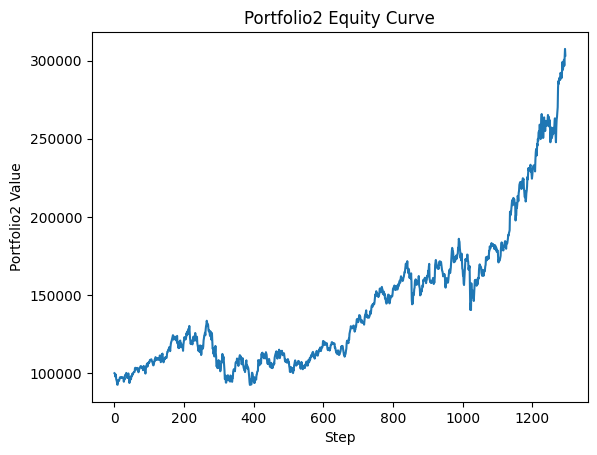

In [64]:
plt.plot(values2)
plt.title("Portfolio2 Equity Curve")
plt.xlabel("Step")
plt.ylabel("Portfolio2 Value")
plt.show()

In [65]:
turnovers = np.array([h["turnover"] for h in test_env_small.history])
costs = np.array([h["transaction_cost"] for h in test_env_small.history])

print("Avg daily turnover:", turnovers.mean())
print("Median daily turnover:", np.median(turnovers))
print("Max daily turnover:", turnovers.max())
print("Total turnover:", turnovers.sum())

print("Avg daily cost drag:", costs.mean())
print("Approx annual cost drag:", costs.mean() * 252)

Avg daily turnover: 0.09727456556690649
Median daily turnover: 0.07599163055419922
Max daily turnover: 1.0
Total turnover: 125.9705624091439
Avg daily cost drag: 0.00017721937053482073
Approx annual cost drag: 0.044659281374774824


In [34]:
import PortfolioManagement
importlib.reload(PortfolioManagement)
from PortfolioManagement import summarize_rl_results

summary_base = summarize_rl_results(
    name="PPO_Jiang_Base",
    results=results_base,
    model=model_base,
    export_path="experiment_results.xlsx",
)

summary_pvm = summarize_rl_results(
    name="PPO_Jiang_LightPVM",
    results=results_pvm,
    model=model_pvm,
    export_path="experiment_results.xlsx",
)

comparison = pd.concat(
    [summary_base, summary_pvm],
    ignore_index=True
)

print(comparison.T)

Results exported to: experiment_results.xlsx
Results exported to: experiment_results_v2.xlsx
                                           0                    1
Timestamp                2026-05-17 13:34:36  2026-05-17 13:34:36
Model                         PPO_Jiang_Base   PPO_Jiang_LightPVM
Final Value                    303189.076487        242829.039472
Total Return                        2.031891              1.42829
Annualized Return                   0.240906              0.18844
Volatility                          0.252339             0.232568
Sharpe                              0.981977             0.858868
Sortino                             1.390787              1.21917
Calmar                              0.783889             0.574545
Max Drawdown                       -0.307321            -0.327982
Avg Daily Turnover                  0.097275             0.050408
Median Daily Turnover               0.075992             0.045269
Max Daily Turnover                       1.0     

## **1.4. Benchmark: Equal Weights**

In [29]:
import PortfolioManagement
importlib.reload(PortfolioManagement)
from PortfolioManagement import make_test_env
from PortfolioManagement import run_equal_weight_daily_rebalanced

ew_env = make_test_env(
    PM_Environment2,
    price_tensor=price_tensor_small[1:],
    cost_tensor=cost_tensor_small,
    feature_tensor=full_feature_tensor,
    feature_mask=feature_mask_small,
    tickers=tickers,
    lookback=30,
    train_ratio=0.8,
)

ew_results = run_equal_weight_daily_rebalanced(ew_env)

ew_summary = summarize_rl_results(
    name="Equal_Weight_Daily_Rebalanced",
    results=ew_results,
    export_path="experiment_results.xlsx",
)

print(ew_summary.T)

Results exported to: experiment_results_v23.xlsx
                                                     0
Timestamp                          2026-05-18 17:11:09
Model                    Equal_Weight_Daily_Rebalanced
Final Value                              327327.721862
Total Return                                  2.273277
Annualized Return                             0.259543
Volatility                                    0.215519
Sharpe                                        1.178807
Sortino                                       1.703013
Calmar                                        1.014672
Max Drawdown                                  -0.25579
Avg Daily Turnover                            0.013741
Median Daily Turnover                         0.011929
Max Daily Turnover                                 1.0
Total Turnover                               17.794301
Avg Daily Cost Drag                           0.000028
Median Daily Cost Drag                        0.000021
Max Daily Cost D

## **1.5. Benchmark: Equal Weights Buy & Hold**

In [30]:
import PortfolioManagement
importlib.reload(PortfolioManagement)
from PortfolioManagement import run_equal_weight_buy_and_hold_direct
from PortfolioManagement import make_test_env

# Fresh env just to get Start & End test indexes
tmp_env = make_test_env(
    PM_Environment2,
    price_tensor=price_tensor_small[1:],
    cost_tensor=cost_tensor_small,
    feature_tensor=full_feature_tensor,
    feature_mask=feature_mask_small,
    tickers=tickers,
    lookback=30,
    train_ratio=0.8,
)

bh_results = run_equal_weight_buy_and_hold_direct(
    price_tensor=price_tensor_small[1:],
    feature_tensor=full_feature_tensor,
    feature_mask=feature_mask_small,
    cost_tensor=cost_tensor_small,
    start_index=tmp_env.start_index,
    end_index=tmp_env.end_index,
    initial_cash=100_000,
    log_ret_c_index=3,
)

bh_summary = summarize_rl_results(
    name="Equal_Weight_Buy_&_Hold",
    results=bh_results,
    export_path="experiment_results.xlsx",
)

print(bh_summary.T)

Results exported to: experiment_results_v24.xlsx
                                               0
Timestamp                    2026-05-18 17:11:12
Model                    Equal_Weight_Buy_&_Hold
Final Value                        443345.881223
Total Return                            3.448174
Annualized Return                       0.337004
Volatility                              0.232065
Sharpe                                  1.368384
Sortino                                 1.902162
Calmar                                  1.338798
Max Drawdown                           -0.251721
Avg Daily Turnover                      0.000772
Median Daily Turnover                        0.0
Max Daily Turnover                           1.0
Total Turnover                               1.0
Avg Daily Cost Drag                     0.000003
Median Daily Cost Drag                       0.0
Max Daily Cost Drag                     0.003308
Total Cost Drag                         0.003308
Approx Annual Cost D

## **1.6. Benchmark: Markowitz**

In [31]:
import PortfolioManagement
importlib.reload(PortfolioManagement)
from PortfolioManagement import run_markowitz_benchmark
from PortfolioManagement import make_test_env

# Fresh env for Markowitz
mk_env = make_test_env(
    PM_Environment2,
    price_tensor=price_tensor_small[1:],
    cost_tensor=cost_tensor_small,
    feature_tensor=full_feature_tensor,
    feature_mask=feature_mask_small,
    tickers=tickers,
    lookback=30,
    train_ratio=0.8,
)

markowitz_results = run_markowitz_benchmark(
    mk_env,
    estimation_window=252,
    rebalance_frequency=21,
    verbose=True,
)

Markowitz successes: 62
Markowitz failures: 0


In [32]:
markowitz_summary = summarize_rl_results(
    name="Markowitz",
    results=markowitz_results,
    export_path="experiment_results.xlsx",
)

print(markowitz_summary.T)

Results exported to: experiment_results_v25.xlsx
                                           0
Timestamp                2026-05-18 17:11:20
Model                              Markowitz
Final Value                    481757.157955
Total Return                        3.817572
Annualized Return                   0.357922
Volatility                          0.235797
Sharpe                              1.416358
Sortino                             1.972709
Calmar                              1.669007
Max Drawdown                       -0.214452
Avg Daily Turnover                  0.030878
Median Daily Turnover               0.010513
Max Daily Turnover                   1.18074
Total Turnover                     39.986473
Avg Daily Cost Drag                 0.000058
Median Daily Cost Drag               0.00002
Max Daily Cost Drag                 0.003243
Total Cost Drag                     0.075579
Approx Annual Cost Drag             0.014707


In [86]:
w = markowitz_results["weights_history"]
print(w[:, :-1].max(), w[:, :-1].min())
print(w.sum(axis=1).min(), w.sum(axis=1).max())

0.25000998 0.0
0.99999994 1.0


## **1.7. Strategy Comparison**

In [87]:
comparison = pd.concat(
    [
        summary_base,
        summary_pvm,
        bh_summary,
        ew_summary,
        markowitz_summary,
    ],
    ignore_index=True
)

print(comparison.T)

                                           0                    1  \
Timestamp                2026-05-17 13:34:36  2026-05-17 13:34:36   
Model                         PPO_Jiang_Base   PPO_Jiang_LightPVM   
Final Value                    303189.076487        242829.039472   
Total Return                        2.031891              1.42829   
Annualized Return                   0.240906              0.18844   
Volatility                          0.252339             0.232568   
Sharpe                              0.981977             0.858868   
Sortino                             1.390787              1.21917   
Calmar                              0.783889             0.574545   
Max Drawdown                       -0.307321            -0.327982   
Avg Daily Turnover                  0.097275             0.050408   
Median Daily Turnover               0.075992             0.045269   
Max Daily Turnover                       1.0             0.952755   
Total Turnover                    

# **2. RL Experimentation**

In [9]:
import RL_Model2
importlib.reload(RL_Model2)
from RL_Model2 import agent_ppo2
from RL_Model2 import evaluate_model2

import PortfolioManagement
importlib.reload(PortfolioManagement)
from PortfolioManagement import set_global_seed
from PortfolioManagement import run_ppo_seed_experiments
from PortfolioManagement import make_test_env
from PortfolioManagement import summarize_rl_results



## **2.1. Log Return On Prices & Volume Features Only (Jiang et al. 2017): 7 Seeds**

In [142]:
seeds = [7, 11, 23, 42, 101]
reduced_feature_seeds = [7, 11, 23, 42, 101, 1499, 1542]

In [143]:
market_only_features = [
    "logRet_O",
    "logRet_H",
    "logRet_L",
    "logRet_C",
    "logVol_change",
]

market_only_indices = [
    full_feature_names.index(f)
    for f in market_only_features
]

full_feature_tensor_market_only = full_feature_tensor[:, :, market_only_indices]

print(full_feature_tensor_market_only.shape)
print(market_only_features)

assert market_only_features[3] == "logRet_C"

(6627, 14, 5)
['logRet_O', 'logRet_H', 'logRet_L', 'logRet_C', 'logVol_change']


In [ ]:
market_only_summary, market_only_results = run_ppo_seed_experiments(
    seeds=reduced_feature_seeds,

    price_tensor_aligned=price_tensor_small_aligned,
    cost_tensor=cost_tensor_small,
    full_feature_tensor=full_feature_tensor_market_only,
    feature_mask=feature_mask_small,
    tickers=tickers,

    lookback=30,
    train_ratio=0.8,
    initial_cash=100_000,
    total_timesteps=100_000,

    export_path="ppo_market_only_results.xlsx",
)

#133m 11.7s


===== SEED 7 | PPO BASE =====
Using cuda device


d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 232  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 204          |
|    iterations           | 2            |
|    time_elapsed         | 20           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0002375026 |
|    clip_fraction        | 0.00908      |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | -31          |
|    learning_rate        | 5e-05        |
|    loss                 | 0.00422      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00586     |
|    std                  | 0.999        |
|    value_loss           | 0.0702       |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 249  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 236           |
|    iterations           | 2             |
|    time_elapsed         | 17            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00023354433 |
|    clip_fraction        | 0.00903       |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | -26.2         |
|    learning_rate        | 5e-05         |
|    loss                 | 0.00329       |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00586      |
|    std                  | 1             |
|    value_loss           | 0.0612        

...

-----------------------------
| time/              |      |
|    fps             | 178  |
|    iterations      | 1    |
|    time_elapsed    | 11   |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 160           |
|    iterations           | 2             |
|    time_elapsed         | 25            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00025887787 |
|    clip_fraction        | 0.00972       |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | -26           |
|    learning_rate        | 5e-05         |
|    loss                 | 0.00063       |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00604      |
|    std                  | 1             |
|    value_loss           | 0.0509        

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 173  |
|    iterations      | 1    |
|    time_elapsed    | 11   |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 158           |
|    iterations           | 2             |
|    time_elapsed         | 25            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00025822019 |
|    clip_fraction        | 0.0101        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | -24.5         |
|    learning_rate        | 5e-05         |
|    loss                 | 0.000604      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00624      |
|    std                  | 1             |
|    value_loss           | 0.0526        

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 174  |
|    iterations      | 1    |
|    time_elapsed    | 11   |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 158          |
|    iterations           | 2            |
|    time_elapsed         | 25           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0002457545 |
|    clip_fraction        | 0.01         |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | -22.6        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00469     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00591     |
|    std                  | 1            |
|    value_loss           | 0.0439       |
----------------

In [220]:
# Save experiment results

import pickle

with open("market_only_results.pkl", "wb") as f:
    pickle.dump(market_only_results, f)

print("Saved market_only_results.pkl")


with open("market_only_summary.pkl", "wb") as f:
    pickle.dump(market_only_summary, f)

print("Saved market_only_summary.pkl")

Saved market_only_results.pkl
Saved market_only_summary.pkl


In [145]:
market_only_summary["Model"] = (
    market_only_summary["Model"]
    + "_MarketOnly"
)

agg_market_only = (
    market_only_summary
    .assign(
        Model_Group=lambda x:
        x["Model"].str.replace(r"_seed_\d+", "", regex=True)
    )
    .groupby("Model_Group")[metrics]
    .agg(["mean", "std"])
)

print(agg_market_only)

                                Final Value              Total Return  \
                                       mean          std         mean   
Model_Group                                                             
PPO_Jiang_Base_MarketOnly      12353.730554  5383.025204    -0.876463   
PPO_Jiang_LightPVM_MarketOnly  14443.420618  2771.335579    -0.855566   

                                        Annualized Return          Volatility  \
                                    std              mean      std       mean   
Model_Group                                                                     
PPO_Jiang_Base_MarketOnly      0.053830         -0.340995  0.04794   0.219012   
PPO_Jiang_LightPVM_MarketOnly  0.027713         -0.315411  0.02515   0.213393   

                                           Sharpe             Sortino  \
                                    std      mean       std      mean   
Model_Group                                                             
PPO_Jiang

In [158]:
print(market_only_features)
print(full_feature_tensor_market_only.shape)

['logRet_O', 'logRet_H', 'logRet_L', 'logRet_C', 'logVol_change']
(6627, 14, 5)


In [159]:
full_feature_tensor_market_only[:, :, 3]

array([[-0.0040983 ,  0.05226843,         nan, ..., -0.01785634,
        -0.04355229, -0.0478196 ],
       [-0.00411516,  0.10431831,         nan, ...,  0.0088966 ,
        -0.05123452,  0.008254  ],
       [-0.04211078, -0.0415174 ,         nan, ...,  0.        ,
         0.00757098, -0.06006424],
       ...,
       [ 0.00024567,  0.00410776,  0.0278947 , ...,  0.0222442 ,
         0.04699965,  0.04395716],
       [ 0.00368906,  0.01743271,  0.00040484, ..., -0.03514707,
        -0.02963726, -0.03045647],
       [-0.0166475 , -0.03173363,  0.00441725, ...,  0.00531535,
         0.05834648,  0.13065369]], shape=(6627, 14))

### **Add Smoothing**

In [176]:
# Smoothed Environments
import PM_Env2
importlib.reload(PM_Env2)
from PM_Env2 import PM_Environment2_s, PM_Environment2_PVM_s


In [180]:
import PortfolioManagement
importlib.reload(PortfolioManagement)

from PortfolioManagement import run_ppo_seed_experiments

In [166]:
smooth_seeds = reduced_feature_seeds

In [181]:
smooth_market_summary, smooth_market_results = run_ppo_seed_experiments(
    seeds=smooth_seeds,

    price_tensor_aligned=price_tensor_small_aligned,
    cost_tensor=cost_tensor_small,
    full_feature_tensor=full_feature_tensor_market_only,
    feature_mask=feature_mask_small,
    tickers=tickers,

    base_env_class=PM_Environment2_s,
    pvm_env_class=PM_Environment2_PVM_s,

    lookback=30,
    train_ratio=0.8,
    initial_cash=100_000,
    total_timesteps=100_000,

    export_path="ppo_smoothing_market_results.xlsx",
)

# 118m 46.8s


===== SEED 7 | PPO BASE =====
Using cuda device


d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 264  |
|    iterations      | 1    |
|    time_elapsed    | 7    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 247           |
|    iterations           | 2             |
|    time_elapsed         | 16            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00023913098 |
|    clip_fraction        | 0.00928       |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | -51           |
|    learning_rate        | 5e-05         |
|    loss                 | 0.00309       |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00586      |
|    std                  | 0.999         |
|    value_loss           | 0.068         

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 254  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 237           |
|    iterations           | 2             |
|    time_elapsed         | 17            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00023618224 |
|    clip_fraction        | 0.00942       |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | -42.6         |
|    learning_rate        | 5e-05         |
|    loss                 | 0.00252       |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00591      |
|    std                  | 1             |
|    value_loss           | 0.0592        

...

-----------------------------
| time/              |      |
|    fps             | 246  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 226          |
|    iterations           | 2            |
|    time_elapsed         | 18           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0002689192 |
|    clip_fraction        | 0.0105       |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | -40          |
|    learning_rate        | 5e-05        |
|    loss                 | -0.000783    |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00596     |
|    std                  | 1            |
|    value_loss           | 0.0482       |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 243  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 228           |
|    iterations           | 2             |
|    time_elapsed         | 17            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00025998795 |
|    clip_fraction        | 0.00977       |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | -38.9         |
|    learning_rate        | 5e-05         |
|    loss                 | 2.23e-05      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00626      |
|    std                  | 1             |
|    value_loss           | 0.0513        

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 219  |
|    iterations      | 1    |
|    time_elapsed    | 9    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 215           |
|    iterations           | 2             |
|    time_elapsed         | 18            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00024686893 |
|    clip_fraction        | 0.011         |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | -35.6         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00367      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00573      |
|    std                  | 1             |
|    value_loss           | 0.0419        

In [219]:
# Save experiment results

import pickle

with open("smooth_market_results.pkl", "wb") as f:
    pickle.dump(smooth_market_results, f)

print("Saved smooth_market_results.pkl")


with open("smooth_market_summary.pkl", "wb") as f:
    pickle.dump(smooth_market_summary, f)

print("Saved smooth_market_summary.pkl")

Saved smooth_market_results.pkl
Saved smooth_market_summary.pkl


In [182]:
smooth_market_summary["Model"] = (
    smooth_market_summary["Model"]
    + "_Smooth_MarketOnly"
)

## **2.2. Complete Feature Tensor: 7 Seeds**

In [ ]:
seeds = [7, 11, 23, 42, 101]
reduced_feature_seeds = [7, 11, 23, 42, 101, 1499, 1542]

In [ ]:


ppo_seed_summary, ppo_seed_results = run_ppo_seed_experiments(
    seeds=reduced_feature_seeds,
    price_tensor_aligned=price_tensor_small_aligned,
    cost_tensor=cost_tensor_small,
    full_feature_tensor=full_feature_tensor,
    feature_mask=feature_mask_small,
    tickers=tickers,
    total_timesteps=100_000,
)

# seeds; 81m 35.5s


===== SEED 7 | PPO BASE =====
Using cuda device


d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 241  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 227          |
|    iterations           | 2            |
|    time_elapsed         | 18           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0006325629 |
|    clip_fraction        | 0.126        |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | 0.666        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00345     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00537     |
|    std                  | 1            |
|    value_loss           | 0.0184       |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 164  |
|    iterations      | 1    |
|    time_elapsed    | 12   |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 157           |
|    iterations           | 2             |
|    time_elapsed         | 26            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00052675745 |
|    clip_fraction        | 0.0899        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | -0.11         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00373      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00483      |
|    std                  | 1             |
|    value_loss           | 0.0163        

...

-----------------------------
| time/              |      |
|    fps             | 162  |
|    iterations      | 1    |
|    time_elapsed    | 12   |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 147          |
|    iterations           | 2            |
|    time_elapsed         | 27           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005937291 |
|    clip_fraction        | 0.109        |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | 0.721        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00669     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00562     |
|    std                  | 1            |
|    value_loss           | 0.0133       |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 265  |
|    iterations      | 1    |
|    time_elapsed    | 7    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 244          |
|    iterations           | 2            |
|    time_elapsed         | 16           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005416739 |
|    clip_fraction        | 0.108        |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | 0.357        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00404     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00499     |
|    std                  | 1            |
|    value_loss           | 0.0168       |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 219  |
|    iterations      | 1    |
|    time_elapsed    | 9    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 212          |
|    iterations           | 2            |
|    time_elapsed         | 19           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005361646 |
|    clip_fraction        | 0.083        |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | -2.84        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00434     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00425     |
|    std                  | 1            |
|    value_loss           | 0.00986      |
----------------

In [217]:
# Save experiment results

import pickle

with open("ppo_seed_results.pkl", "wb") as f:
    pickle.dump(ppo_seed_results, f)

print("Saved ppo_seed_results.pkl")

with open("ppo_seed_summary.pkl", "wb") as f:
    pickle.dump(ppo_seed_summary, f)

print("Saved ppo_seed_summary.pkl")

Saved ppo_seed_results.pkl
Saved ppo_seed_summary.pkl


In [92]:
metrics = [
    "Final Value",
    "Total Return",
    "Annualized Return",
    "Volatility",
    "Sharpe",
    "Sortino",
    "Calmar",
    "Max Drawdown",
    "Avg Daily Turnover",
    "Approx Annual Cost Drag",
]

agg = (
    ppo_seed_summary
    .assign(Model_Group=lambda x: x["Model"].str.replace(r"_seed_\d+", "", regex=True))
    .groupby("Model_Group")[metrics]
    .agg(["mean", "std"])
)

print(agg)

                      Final Value               Total Return            \
                             mean           std         mean       std   
Model_Group                                                              
PPO_Jiang_Base      261656.149229  97518.409590     1.616561  0.975184   
PPO_Jiang_LightPVM  226097.759795  62979.158383     1.260978  0.629792   

                   Annualized Return           Volatility              Sharpe  \
                                mean       std       mean       std      mean   
Model_Group                                                                     
PPO_Jiang_Base              0.196939  0.074651   0.213614  0.018699  0.933366   
PPO_Jiang_LightPVM          0.165878  0.063877   0.222445  0.014283  0.799552   

                               Sortino              Calmar            \
                         std      mean       std      mean       std   
Model_Group                                                            
PPO_Jia

In [95]:
ppo_seed_summary.to_excel(
    "ppo_seed_summary7.xlsx",
    index=False
)

print("Saved ppo_seed_summary7.xlsx")

Saved ppo_seed_summary7.xlsx


### **Add Smoothing**

In [ ]:
smooth_full_summary, smooth_full_results = run_ppo_seed_experiments(
    seeds=smooth_seeds,

    price_tensor_aligned=price_tensor_small_aligned,
    cost_tensor=cost_tensor_small,
    full_feature_tensor=full_feature_tensor,
    feature_mask=feature_mask_small,
    tickers=tickers,

    base_env_class=PM_Environment2_s,
    pvm_env_class=PM_Environment2_PVM_s,

    lookback=30,
    train_ratio=0.8,
    initial_cash=100_000,
    total_timesteps=100_000,

    export_path="ppo_smoothing_full_results.xlsx",
)

#111m 53.2s


===== SEED 7 | PPO BASE =====
Using cuda device


d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 232  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 217           |
|    iterations           | 2             |
|    time_elapsed         | 18            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00067188975 |
|    clip_fraction        | 0.131         |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.695         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00475      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.0054       |
|    std                  | 1             |
|    value_loss           | 0.0148        

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 235  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 223          |
|    iterations           | 2            |
|    time_elapsed         | 18           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005985546 |
|    clip_fraction        | 0.115        |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | 0.248        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00862     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00562     |
|    std                  | 1            |
|    value_loss           | 0.0124       |
----------------

...

-----------------------------
| time/              |      |
|    fps             | 247  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 226           |
|    iterations           | 2             |
|    time_elapsed         | 18            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00058695953 |
|    clip_fraction        | 0.117         |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.708         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00674      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00564      |
|    std                  | 1             |
|    value_loss           | 0.013         

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 251  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 231          |
|    iterations           | 2            |
|    time_elapsed         | 17           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005206743 |
|    clip_fraction        | 0.0997       |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | 0.261        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00437     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00483     |
|    std                  | 1            |
|    value_loss           | 0.0155       |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 247  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 224           |
|    iterations           | 2             |
|    time_elapsed         | 18            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00049636466 |
|    clip_fraction        | 0.0725        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | -2.81         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00352      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00409      |
|    std                  | 1             |
|    value_loss           | 0.0147        

In [214]:
# Save experiment results
import pickle

with open("smooth_full_results.pkl", "wb") as f:
    pickle.dump(smooth_full_results, f)

print("Saved smooth_full_results.pkl")


with open("smooth_full_summary.pkl", "wb") as f:
    pickle.dump(smooth_full_summary, f)

print("Saved smooth_full_summary.pkl")

Saved smooth_full_results.pkl
Saved smooth_full_summary.pkl


In [184]:
smooth_full_summary["Model"] = (
    smooth_full_summary["Model"]
    + "_Smooth_Full"
)

## **2.3. Complete Feature Tensor: 30 Seeds**

In [ ]:
with open("ppo_seed_results5.pkl", "rb") as f:
    ppo_seed_results = pickle.load(f)

In [11]:
new_seeds = [random.randint(0, 10000) for _ in range(25)]


In [12]:
print(new_seeds)

[3923, 7387, 1499, 8065, 8599, 1991, 4690, 5209, 6481, 4587, 2692, 7233, 1628, 6386, 7332, 5843, 5900, 9350, 6599, 3807, 4186, 3434, 4062, 6742, 1542]


In [13]:
for i in range(0, len(new_seeds)):
    if i<len(new_seeds)-1:
        if new_seeds[i]==new_seeds[i+1]:
            print(f"Two identical seeds!! in {i} & {i+1}")
            break
        
print(f"All seeds are distinct!") 

All seeds are distinct!


In [14]:
import pickle

with open("new_seeds.pkl", "wb") as f:
    pickle.dump(new_seeds, f)

print("Saved new_seeds.pkl")

Saved new_seeds.pkl


In [15]:
with open("new_seeds.pkl", "rb") as f:
    new_seeds = pickle.load(f)

In [16]:
print(f"Is GPU available? {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")

Is GPU available? True
GPU Name: NVIDIA GeForce GTX 1650 with Max-Q Design
Number of GPUs: 1


In [17]:
import PortfolioManagement
importlib.reload(PortfolioManagement)
from PortfolioManagement import run_additional_ppo_seeds


new_summary, ppo_seed_results = run_additional_ppo_seeds(
    seeds=new_seeds,
    existing_results_path="ppo_seed_results.pkl",
    export_path="ppo_multiseed_results.xlsx",

    price_tensor_aligned=price_tensor_small_aligned,
    cost_tensor=cost_tensor_small,
    full_feature_tensor=full_feature_tensor,
    feature_mask=feature_mask_small,
    tickers=tickers,
    lookback=30,
    train_ratio=0.8,
    initial_cash=100_000,
    total_timesteps=100_000,
)

# 401m 22.8s

Loaded existing seed results from ppo_seed_results.pkl

===== SEED 3923 | PPO BASE =====
Using cuda device


d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 253  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 228           |
|    iterations           | 2             |
|    time_elapsed         | 17            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00064692926 |
|    clip_fraction        | 0.121         |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.736         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.004        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00607      |
|    std                  | 1             |
|    value_loss           | 0.0156        

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 246  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 229           |
|    iterations           | 2             |
|    time_elapsed         | 17            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00057764514 |
|    clip_fraction        | 0.108         |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.815         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00466      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00498      |
|    std                  | 1             |
|    value_loss           | 0.0174        

...

-----------------------------
| time/              |      |
|    fps             | 275  |
|    iterations      | 1    |
|    time_elapsed    | 7    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 251          |
|    iterations           | 2            |
|    time_elapsed         | 16           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005313307 |
|    clip_fraction        | 0.106        |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | 0.78         |
|    learning_rate        | 5e-05        |
|    loss                 | -0.0064      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00519     |
|    std                  | 1            |
|    value_loss           | 0.0145       |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 253  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 238          |
|    iterations           | 2            |
|    time_elapsed         | 17           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005416739 |
|    clip_fraction        | 0.108        |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | 0.357        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00404     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00499     |
|    std                  | 1            |
|    value_loss           | 0.0168       |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 266  |
|    iterations      | 1    |
|    time_elapsed    | 7    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 246          |
|    iterations           | 2            |
|    time_elapsed         | 16           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005361646 |
|    clip_fraction        | 0.083        |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | -2.84        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00434     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00425     |
|    std                  | 1            |
|    value_loss           | 0.00986      |
----------------

In [18]:
import pickle

with open("ppo_seed_results.pkl", "rb") as f:
    ppo_seed_results = pickle.load(f)



dict_keys(['PPO_Base_7', 'PPO_PVM_7', 'PPO_Base_11', 'PPO_PVM_11', 'PPO_Base_23', 'PPO_PVM_23', 'PPO_Base_42', 'PPO_PVM_42', 'PPO_Base_101', 'PPO_PVM_101', 'PPO_Base_3923', 'PPO_PVM_3923', 'PPO_Base_7387', 'PPO_PVM_7387', 'PPO_Base_1499', 'PPO_PVM_1499', 'PPO_Base_8065', 'PPO_PVM_8065', 'PPO_Base_8599', 'PPO_PVM_8599', 'PPO_Base_1991', 'PPO_PVM_1991', 'PPO_Base_4690', 'PPO_PVM_4690', 'PPO_Base_5209', 'PPO_PVM_5209', 'PPO_Base_6481', 'PPO_PVM_6481', 'PPO_Base_4587', 'PPO_PVM_4587', 'PPO_Base_2692', 'PPO_PVM_2692', 'PPO_Base_7233', 'PPO_PVM_7233', 'PPO_Base_1628', 'PPO_PVM_1628', 'PPO_Base_6386', 'PPO_PVM_6386', 'PPO_Base_7332', 'PPO_PVM_7332', 'PPO_Base_5843', 'PPO_PVM_5843', 'PPO_Base_5900', 'PPO_PVM_5900', 'PPO_Base_9350', 'PPO_PVM_9350', 'PPO_Base_6599', 'PPO_PVM_6599', 'PPO_Base_3807', 'PPO_PVM_3807', 'PPO_Base_4186', 'PPO_PVM_4186', 'PPO_Base_3434', 'PPO_PVM_3434', 'PPO_Base_4062', 'PPO_PVM_4062', 'PPO_Base_6742', 'PPO_PVM_6742', 'PPO_Base_1542', 'PPO_PVM_1542'])


In [27]:
print(ppo_seed_results.keys())

len(list(ppo_seed_results.keys()))

dict_keys(['PPO_Base_7', 'PPO_PVM_7', 'PPO_Base_11', 'PPO_PVM_11', 'PPO_Base_23', 'PPO_PVM_23', 'PPO_Base_42', 'PPO_PVM_42', 'PPO_Base_101', 'PPO_PVM_101', 'PPO_Base_3923', 'PPO_PVM_3923', 'PPO_Base_7387', 'PPO_PVM_7387', 'PPO_Base_1499', 'PPO_PVM_1499', 'PPO_Base_8065', 'PPO_PVM_8065', 'PPO_Base_8599', 'PPO_PVM_8599', 'PPO_Base_1991', 'PPO_PVM_1991', 'PPO_Base_4690', 'PPO_PVM_4690', 'PPO_Base_5209', 'PPO_PVM_5209', 'PPO_Base_6481', 'PPO_PVM_6481', 'PPO_Base_4587', 'PPO_PVM_4587', 'PPO_Base_2692', 'PPO_PVM_2692', 'PPO_Base_7233', 'PPO_PVM_7233', 'PPO_Base_1628', 'PPO_PVM_1628', 'PPO_Base_6386', 'PPO_PVM_6386', 'PPO_Base_7332', 'PPO_PVM_7332', 'PPO_Base_5843', 'PPO_PVM_5843', 'PPO_Base_5900', 'PPO_PVM_5900', 'PPO_Base_9350', 'PPO_PVM_9350', 'PPO_Base_6599', 'PPO_PVM_6599', 'PPO_Base_3807', 'PPO_PVM_3807', 'PPO_Base_4186', 'PPO_PVM_4186', 'PPO_Base_3434', 'PPO_PVM_3434', 'PPO_Base_4062', 'PPO_PVM_4062', 'PPO_Base_6742', 'PPO_PVM_6742', 'PPO_Base_1542', 'PPO_PVM_1542'])


60

In [33]:
import PortfolioManagement
importlib.reload(PortfolioManagement)

from PortfolioManagement import results_to_equity_df

# Equity Curve Dataframe

ppo_equity_df = results_to_equity_df(ppo_seed_results)

benchmark_results = {
    "EW_Daily": ew_results,
    "EW_BuyHold": bh_results,
    "Markowitz": markowitz_results,
}

benchmark_equity_df = results_to_equity_df(benchmark_results)

combined_equity_df = pd.concat(
    [ppo_equity_df, benchmark_equity_df],
    axis=1
)

print(combined_equity_df.head())

   PPO_Base_7  PPO_PVM_7  PPO_Base_11  PPO_PVM_11  PPO_Base_23  PPO_PVM_23  \
0    1.000000   1.000000     1.000000    1.000000     1.000000    1.000000   
1    0.997294   0.997131     0.996998    0.997065     0.997603    0.997297   
2    0.994027   1.001800     1.007326    1.006830     0.996521    1.004016   
3    0.990970   1.006234     1.003607    1.001599     0.994325    0.984835   
4    1.002240   1.022340     1.011687    1.010995     1.004314    0.991927   

   PPO_Base_42  PPO_PVM_42  PPO_Base_101  PPO_PVM_101  ...  PPO_PVM_3434  \
0     1.000000    1.000000      1.000000     1.000000  ...      1.000000   
1     0.998854    0.997138      0.995247     0.997236  ...      0.997016   
2     1.002415    1.001637      1.004929     1.008657  ...      1.003137   
3     0.999949    0.992917      0.998565     1.009193  ...      1.000593   
4     1.004989    0.997427      1.002817     1.017756  ...      1.012027   

   PPO_Base_4062  PPO_PVM_4062  PPO_Base_6742  PPO_PVM_6742  PPO_Base_1542

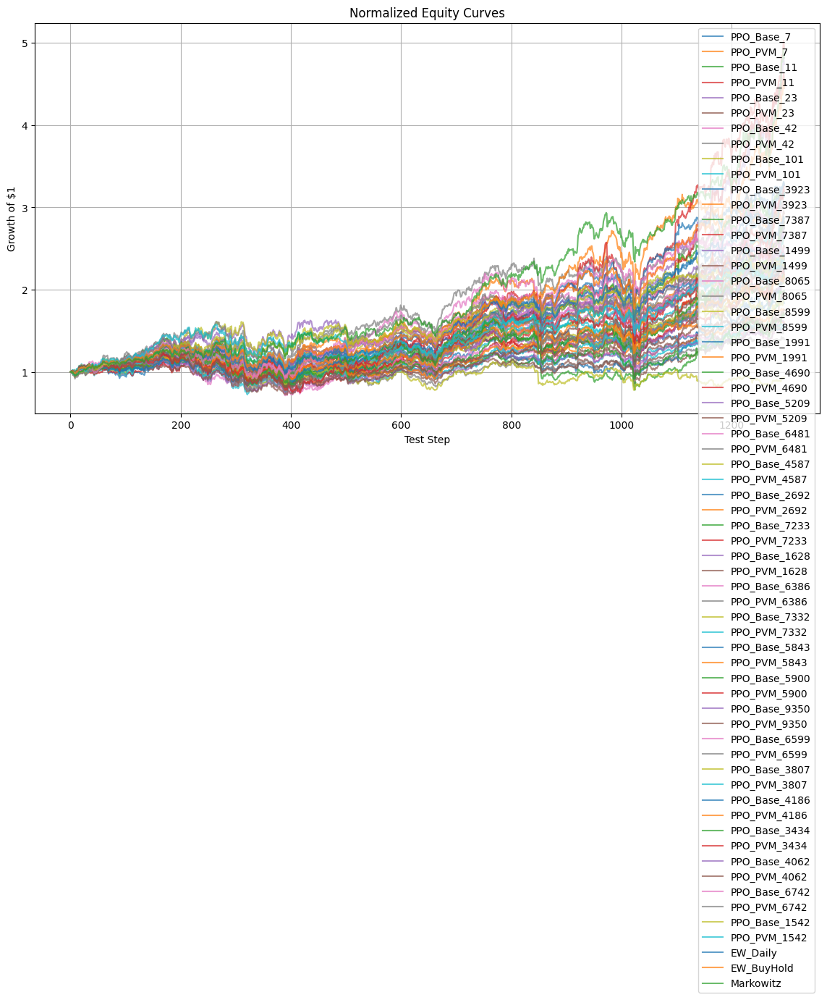

In [ ]:
# Plot Equity Curves (maybe decrease number of test seeds)

plt.figure(figsize=(14, 7))

for col in combined_equity_df.columns:
    plt.plot(
        combined_equity_df.index,
        combined_equity_df[col],
        label=col,
        alpha=0.7
    )

plt.title("Normalized Equity Curves")
plt.xlabel("Test Step")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

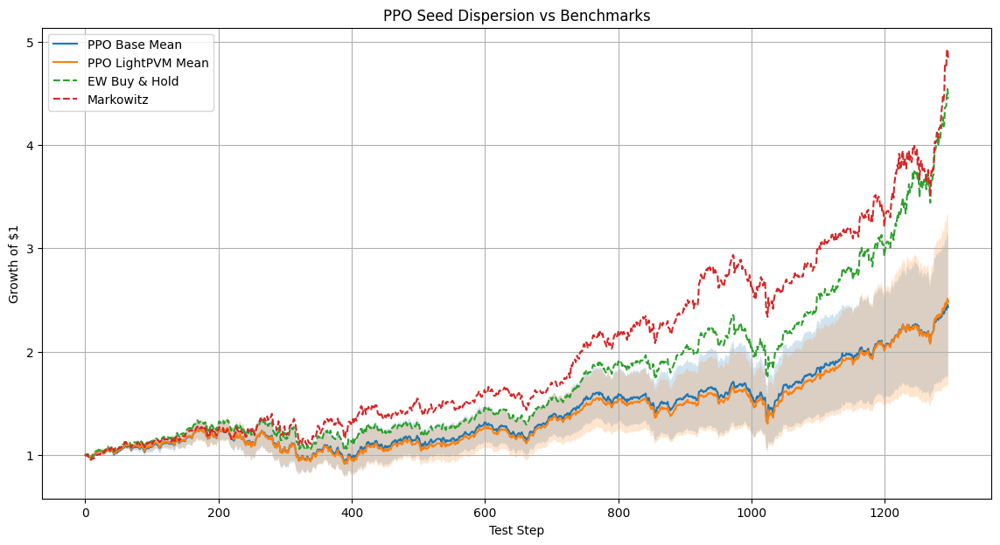

In [35]:
import PortfolioManagement
importlib.reload(PortfolioManagement)

from PortfolioManagement import plot_seed_band

# Plot seed bands

plt.figure(figsize=(14, 7))

plot_seed_band(ppo_equity_df, "PPO_Base", "PPO Base")
plot_seed_band(ppo_equity_df, "PPO_PVM", "PPO LightPVM")

plt.plot(
    benchmark_equity_df["EW_BuyHold"].values,
    label="EW Buy & Hold",
    linestyle="--"
)

plt.plot(
    benchmark_equity_df["Markowitz"].values,
    label="Markowitz",
    linestyle="--"
)

plt.title("PPO Seed Dispersion vs Benchmarks")
plt.xlabel("Test Step")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

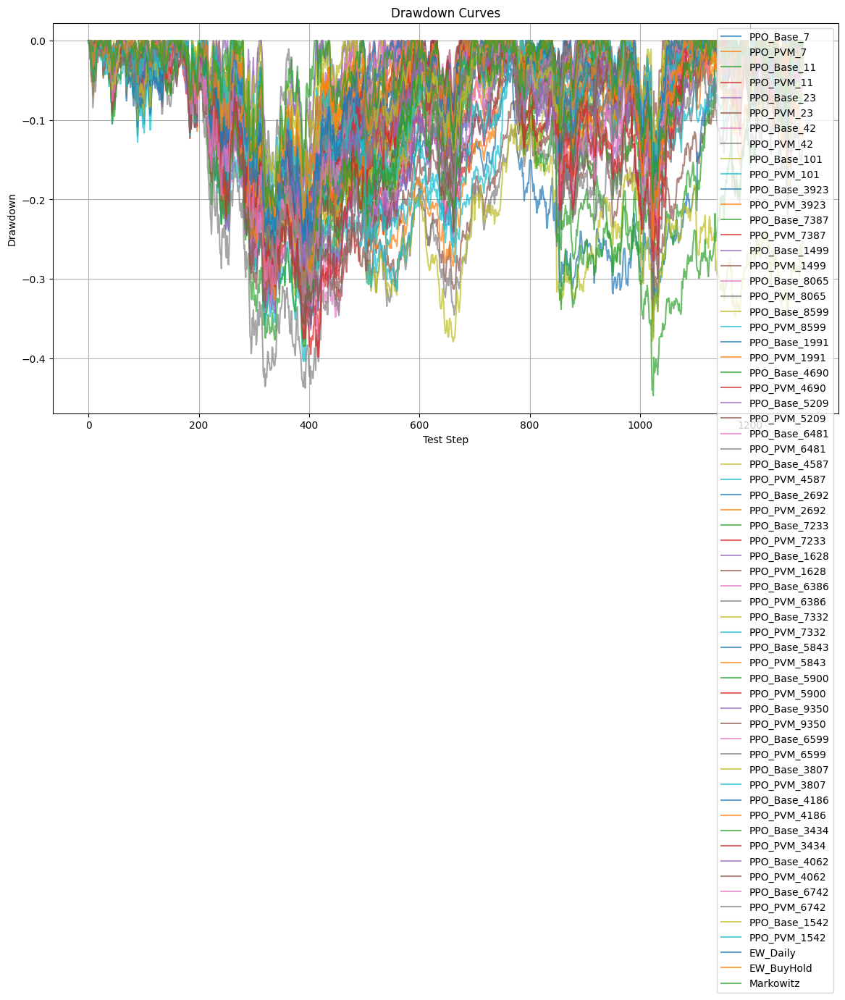

In [ ]:
import PortfolioManagement
importlib.reload(PortfolioManagement)

from PortfolioManagement import drawdown_curve

# Drawdown Curves (maybe decrease number of test seeds)

drawdown_df = combined_equity_df.apply(drawdown_curve, axis=0)

plt.figure(figsize=(14, 7))

for col in drawdown_df.columns:
    plt.plot(
        drawdown_df.index,
        drawdown_df[col],
        label=col,
        alpha=0.7
    )

plt.title("Drawdown Curves")
plt.xlabel("Test Step")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

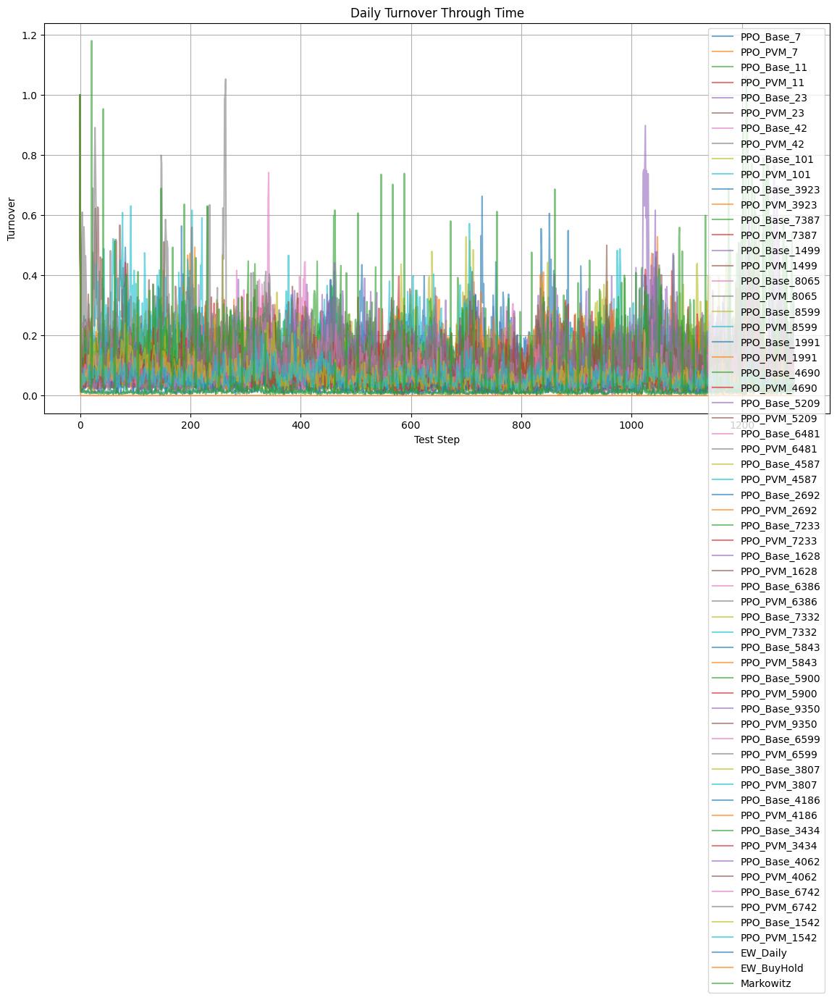

In [ ]:
import PortfolioManagement
importlib.reload(PortfolioManagement)

from PortfolioManagement import history_metric_series

# Daily Turnover Curves (maybe decrease number of test seeds))

turnover_data = {}

for name, result in ppo_seed_results.items():
    turnover_data[name] = history_metric_series(result, "turnover")

turnover_data["EW_Daily"] = history_metric_series(ew_results, "turnover")
turnover_data["EW_BuyHold"] = history_metric_series(bh_results, "turnover")
turnover_data["Markowitz"] = history_metric_series(markowitz_results, "turnover")

turnover_df = pd.DataFrame(turnover_data)

plt.figure(figsize=(14, 7))

for col in turnover_df.columns:
    plt.plot(
        turnover_df.index,
        turnover_df[col],
        label=col,
        alpha=0.6
    )

plt.title("Daily Turnover Through Time")
plt.xlabel("Test Step")
plt.ylabel("Turnover")
plt.legend()
plt.grid(True)
plt.show()

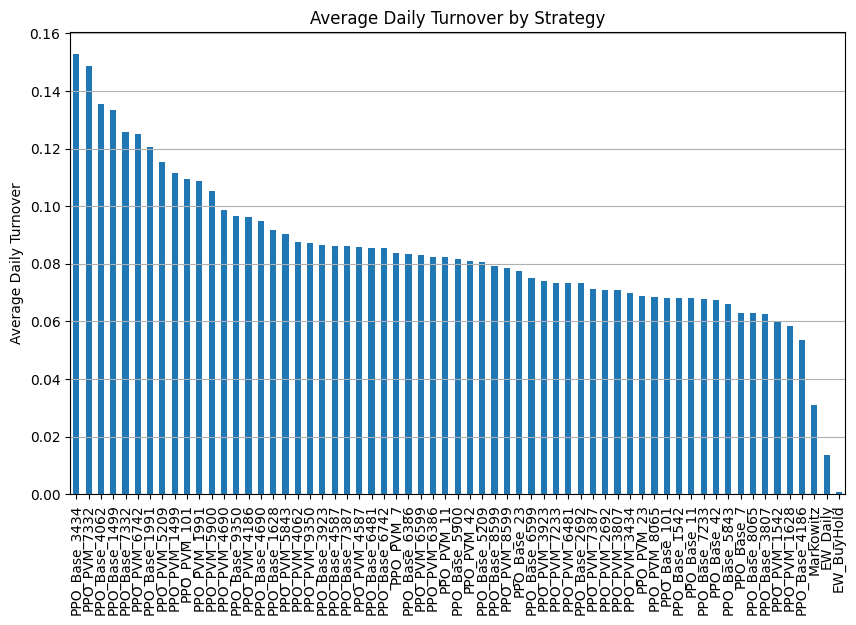

In [39]:
# Average turnover chart - Indicator for overtrading

avg_turnover = turnover_df.mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_turnover.plot(kind="bar")
plt.title("Average Daily Turnover by Strategy")
plt.ylabel("Average Daily Turnover")
plt.grid(axis="y")
plt.show()

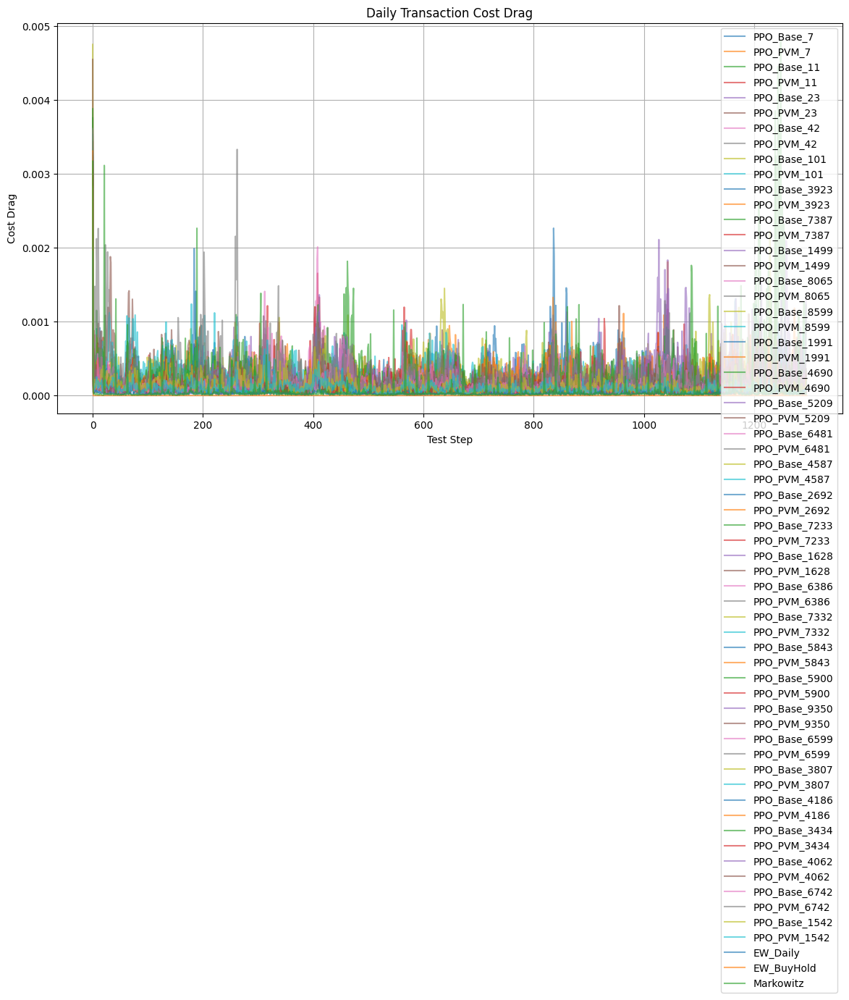

In [ ]:
# Cost Drag Curves (maybe decrease number of test seeds)

cost_data = {}

for name, result in ppo_seed_results.items():
    cost_data[name] = history_metric_series(result, "transaction_cost")

cost_data["EW_Daily"] = history_metric_series(ew_results, "transaction_cost")
cost_data["EW_BuyHold"] = history_metric_series(bh_results, "transaction_cost")
cost_data["Markowitz"] = history_metric_series(markowitz_results, "transaction_cost")

cost_df = pd.DataFrame(cost_data)

plt.figure(figsize=(14, 7))

for col in cost_df.columns:
    plt.plot(
        cost_df.index,
        cost_df[col],
        label=col,
        alpha=0.6
    )

plt.title("Daily Transaction Cost Drag")
plt.xlabel("Test Step")
plt.ylabel("Cost Drag")
plt.legend()
plt.grid(True)
plt.show()

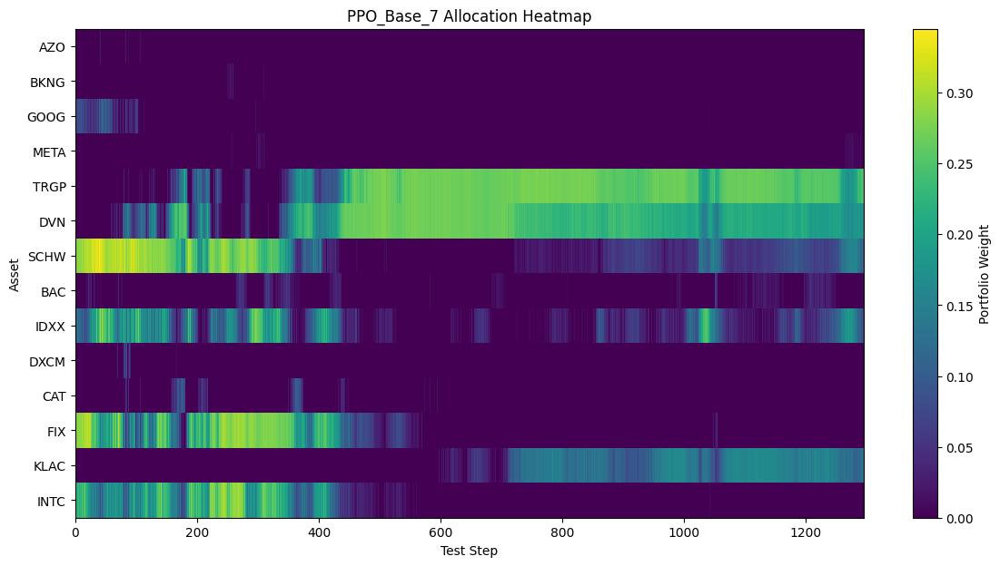

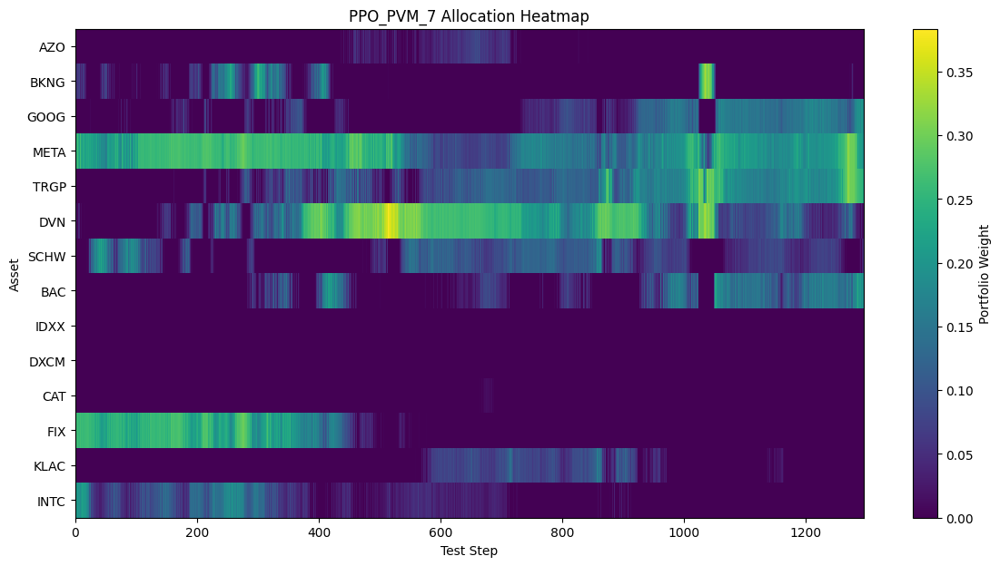

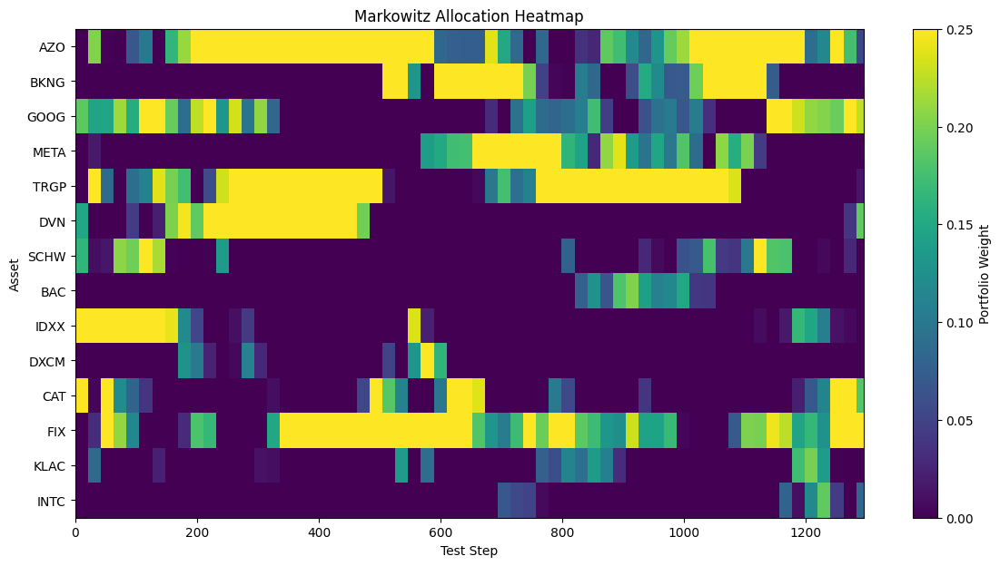

In [41]:
import PortfolioManagement
importlib.reload(PortfolioManagement)

from PortfolioManagement import plot_weights_heatmap

# Portfolio Allocation Heatmaps

first_base_key = [k for k in ppo_seed_results.keys() if k.startswith("PPO_Base")][0]
first_pvm_key = [k for k in ppo_seed_results.keys() if k.startswith("PPO_PVM")][0]

plot_weights_heatmap(
    ppo_seed_results[first_base_key],
    tickers,
    f"{first_base_key} Allocation Heatmap"
)

plot_weights_heatmap(
    ppo_seed_results[first_pvm_key],
    tickers,
    f"{first_pvm_key} Allocation Heatmap"
)

plot_weights_heatmap(
    markowitz_results,
    tickers,
    "Markowitz Allocation Heatmap"
)

In [42]:
with pd.ExcelWriter("diagnostic_plot_data.xlsx", engine="xlsxwriter") as writer:
    combined_equity_df.to_excel(writer, sheet_name="Equity_Curves")
    drawdown_df.to_excel(writer, sheet_name="Drawdowns")
    turnover_df.to_excel(writer, sheet_name="Turnover")
    cost_df.to_excel(writer, sheet_name="Cost_Drag")
    avg_turnover.to_frame("Avg_Turnover").to_excel(writer, sheet_name="Avg_Turnover")

print("Diagnostic data exported to diagnostic_plot_data.xlsx")

Diagnostic data exported to diagnostic_plot_data.xlsx


In [ ]:
benchmark_summary = pd.concat(
    [
        ew_summary,
        bh_summary,
        markowitz_summary,
    ],
    ignore_index=True,
)

combined_summary = pd.concat(
    [
        new_summary,
        benchmark_summary,
    ],
    ignore_index=True,
)


agg_f = (
    combined_summary
    .assign(
        Model_Group=lambda x:
        x["Model"].str.replace(r"_seed_\d+", "", regex=True)
    )
    .groupby("Model_Group")[metrics]
    .agg(["mean", "std"])
)

In [153]:
import pickle

with open("new_summary_25seeds.pkl", "wb") as f:
    pickle.dump(new_summary, f)

print("Saved new_summary_25seeds.pkl.pkl")

Saved new_summary_25seeds.pkl.pkl


In [154]:
import pickle

with open("new_summary_25seeds.pkl", "rb") as f:
    new_summary_25 = pickle.load(f)

print(new_summary_25)

              Timestamp                         Model    Final Value  \
0   2026-05-18 10:08:01      PPO_Jiang_Base_seed_3923  227873.536936   
1   2026-05-18 10:16:09  PPO_Jiang_LightPVM_seed_3923  261669.383611   
2   2026-05-18 10:24:01      PPO_Jiang_Base_seed_7387  316879.728960   
3   2026-05-18 10:31:57  PPO_Jiang_LightPVM_seed_7387  494390.175560   
4   2026-05-18 10:39:51      PPO_Jiang_Base_seed_1499  241949.000643   
5   2026-05-18 10:47:46  PPO_Jiang_LightPVM_seed_1499  191278.360172   
6   2026-05-18 10:55:41      PPO_Jiang_Base_seed_8065  237102.697094   
7   2026-05-18 11:03:36  PPO_Jiang_LightPVM_seed_8065  227845.911064   
8   2026-05-18 11:11:16      PPO_Jiang_Base_seed_8599  208365.211122   
9   2026-05-18 11:19:19  PPO_Jiang_LightPVM_seed_8599  261515.818953   
10  2026-05-18 11:27:19      PPO_Jiang_Base_seed_1991  221493.975827   
11  2026-05-18 11:35:22  PPO_Jiang_LightPVM_seed_1991  279986.661502   
12  2026-05-18 11:43:02      PPO_Jiang_Base_seed_4690  215042.84

In [155]:
import pickle

with open("aggr_final_30seeds_bench.pkl", "wb") as f:
    pickle.dump(agg_f, f)

print("Saved aggr_final_30seeds_bench.pkl")

Saved aggr_final_30seeds_bench.pkl


In [156]:
import pickle

with open("aggr_final_30seeds_bench.pkl", "rb") as f:
    agg_f = pickle.load(f)

print(agg_f)

                                 Final Value               Total Return  \
                                        mean           std         mean   
Model_Group                                                               
Equal_Weight_Buy_&_Hold        443345.881223           NaN     3.448174   
Equal_Weight_Daily_Rebalanced  327327.721862           NaN     2.273277   
Markowitz                      481757.157955           NaN     3.817572   
PPO_Jiang_Base                 237233.518176  57110.339153     1.372335   
PPO_Jiang_LightPVM             251469.988827  86053.281076     1.514700   

                                        Annualized Return            \
                                    std              mean       std   
Model_Group                                                           
Equal_Weight_Buy_&_Hold             NaN          0.337004       NaN   
Equal_Weight_Daily_Rebalanced       NaN          0.259543       NaN   
Markowitz                           NaN     

In [70]:
# For time efficiency, we will work on the results of 7 seeds only

import re

# Extract unique seeds from keys like:
# PPO_Base_7
# PPO_PVM_7

all_seeds = sorted({
    int(re.search(r"_(\d+)$", k).group(1))
    for k in ppo_seed_results.keys()
})

print(all_seeds)

[7, 11, 23, 42, 101, 1499, 1542, 1628, 1991, 2692, 3434, 3807, 3923, 4062, 4186, 4587, 4690, 5209, 5843, 5900, 6386, 6481, 6599, 6742, 7233, 7332, 7387, 8065, 8599, 9350]


In [71]:
reduced_feature_seeds = all_seeds[:7]

print(reduced_feature_seeds)

[7, 11, 23, 42, 101, 1499, 1542]


In [72]:
ppo_seed_results_subset = {
    k: v
    for k, v in ppo_seed_results.items()
    if int(re.search(r"_(\d+)$", k).group(1)) in reduced_feature_seeds
}

In [73]:
print(ppo_seed_results_subset.keys())

dict_keys(['PPO_Base_7', 'PPO_PVM_7', 'PPO_Base_11', 'PPO_PVM_11', 'PPO_Base_23', 'PPO_PVM_23', 'PPO_Base_42', 'PPO_PVM_42', 'PPO_Base_101', 'PPO_PVM_101', 'PPO_Base_1499', 'PPO_PVM_1499', 'PPO_Base_1542', 'PPO_PVM_1542'])


# **3. Random Forests Feature Importance**

In [138]:
full_feature_names = (
    list(market_features)
    + list(firm_features)
    + list(macro_features)
)

assert len(full_feature_names) == full_feature_tensor.shape[2]

print(len(full_feature_names))
print(full_feature_names)
print(full_feature_tensor.shape)

16
['logRet_O', 'logRet_H', 'logRet_L', 'logRet_C', 'logVol_change', 'EPS', 'Revenue', 'DebtToEquity', 'ROE', 'MarketCap', 'FedRate', 'CPI', 'Unemployment', 'US10Y', 'VIX', 'GDP']
(6627, 14, 16)


In [139]:
import PortfolioManagement
importlib.reload(PortfolioManagement)

from PortfolioManagement import build_rf_feature_dataset



In [262]:
X_rf, y_rf = build_rf_feature_dataset(
    full_feature_tensor=full_feature_tensor,
    feature_mask=feature_mask_small,
    log_ret_c_index=3,
)

print(X_rf.shape)
print(y_rf.shape)

(6626, 16)
(6626,)


In [265]:
print(y_rf)

[ 0.01620313  0.00500147  0.0258412  ...  0.00789727 -0.01163426
  0.00558587]


In [113]:
split = int(len(X_rf) * 0.8)

X_train, X_test = X_rf[:split], X_rf[split:]
y_train, y_test = y_rf[:split], y_rf[split:]

In [114]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

pred_train = rf.predict(X_train)
pred_test = rf.predict(X_test)

print("Train R2:", r2_score(y_train, pred_train))
print("Test R2:", r2_score(y_test, pred_test))
print("Test MSE:", mean_squared_error(y_test, pred_test))

Train R2: 0.08003306926414122
Test R2: -0.024853760421116755
Test MSE: 0.00019008980113173636


In [115]:
importance_df = pd.DataFrame({
    "Feature": full_feature_names,
    "Importance": rf.feature_importances_,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(importance_df)

top_k = 8

          Feature  Importance
0        logRet_L    0.299242
1             VIX    0.276535
2        logRet_H    0.092491
3        logRet_O    0.067210
4        logRet_C    0.063966
5           US10Y    0.038863
6   logVol_change    0.029516
7             ROE    0.027971
8             EPS    0.022565
9         FedRate    0.021900
10   Unemployment    0.018270
11   DebtToEquity    0.014675
12        Revenue    0.010711
13            CPI    0.007822
14            GDP    0.005523
15      MarketCap    0.002742


In [141]:
# Mandatory Jiang/core market features
mandatory_features = [
    "logRet_O",
    "logRet_H",
    "logRet_L",
    "logRet_C",
]

# Optional RF-selectable features
candidate_features = [
    f for f in full_feature_names
    if f not in mandatory_features
]

candidate_importance_df = importance_df[
    importance_df["Feature"].isin(candidate_features)
].copy()

top_k_extra = top_k - len(mandatory_features)   # choose how many extra macro/firm/features to add

selected_extra_features = (
    candidate_importance_df
    .head(top_k_extra)["Feature"]
    .tolist()
)

selected_features_rf_fixed = (
    mandatory_features
    + selected_extra_features
)

selected_indices_rf_fixed = [
    full_feature_names.index(f)
    for f in selected_features_rf_fixed
]

print("Selected features:")
print(selected_features_rf_fixed)

print("Selected indices:")
print(selected_indices_rf_fixed)

Selected features:
['logRet_O', 'logRet_H', 'logRet_L', 'logRet_C', 'VIX', 'US10Y', 'logVol_change', 'ROE']
Selected indices:
[0, 1, 2, 3, 14, 13, 4, 8]


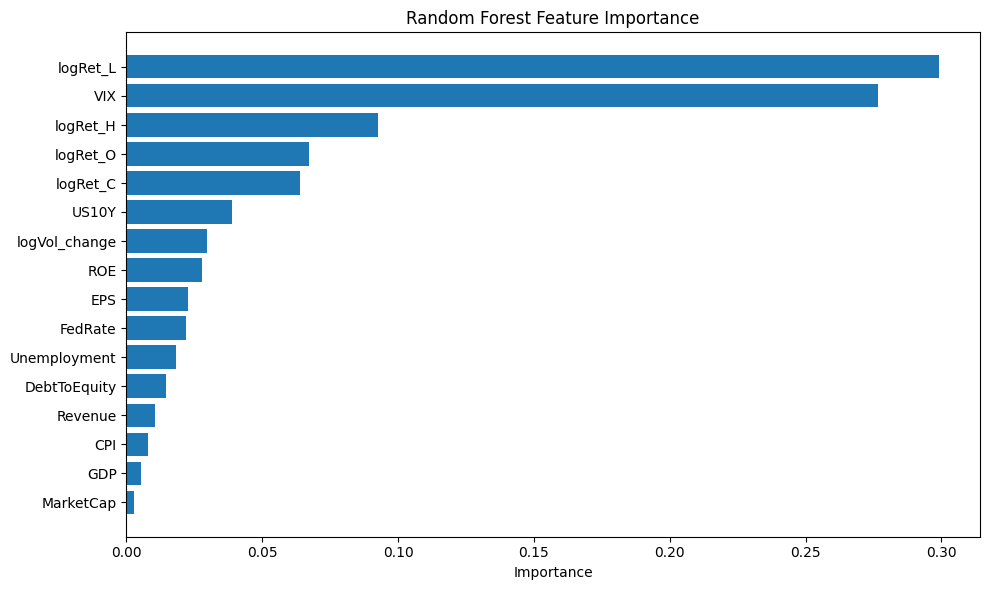

In [117]:
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [118]:
# This is just a list of the original indexes of the selected features

selected_features = importance_df.head(top_k)["Feature"].tolist()

selected_indices = [
    full_feature_names.index(f)
    for f in selected_features
]

print(selected_features)
print(selected_indices)

['logRet_L', 'VIX', 'logRet_H', 'logRet_O', 'logRet_C', 'US10Y', 'logVol_change', 'ROE']
[2, 14, 1, 0, 3, 13, 4, 8]


In [119]:
full_feature_tensor_rf_fixed = full_feature_tensor[:, :, selected_indices_rf_fixed]

print(full_feature_tensor_rf_fixed.shape)
print(selected_features_rf_fixed)

(6627, 14, 8)
['logRet_O', 'logRet_H', 'logRet_L', 'logRet_C', 'VIX', 'US10Y', 'logVol_change', 'ROE']


In [120]:
assert selected_features_rf_fixed[0] == "logRet_O"
assert selected_features_rf_fixed[1] == "logRet_H"
assert selected_features_rf_fixed[2] == "logRet_L"
assert selected_features_rf_fixed[3] == "logRet_C"

In [140]:
np.save(
    "frozen_dataset/full_feature_tensor_reduced.npy",
    full_feature_tensor_rf_fixed
)

importance_df.to_excel(
    "rf_feature_importance.xlsx",
    index=False
)

pd.Series(selected_features_rf_fixed).to_csv(
    "selected_features_rf.csv",
    index=False,
    header=["Feature"]
)

In [128]:
import PortfolioManagement
importlib.reload(PortfolioManagement)

import PM_Env2
importlib.reload(PM_Env2)

<module 'PM_Env2' from 'd:\\NewFolder\\Anas\\LU\\Spring2026\\Thesis\\ThesisCode\\StocksData\\PM_Env2.py'>

In [ ]:
reduced_summary, reduced_results = run_ppo_seed_experiments(
    seeds=reduced_feature_seeds,

    price_tensor_aligned=price_tensor_small_aligned,
    cost_tensor=cost_tensor_small,
    full_feature_tensor=full_feature_tensor_rf_fixed,
    feature_mask=feature_mask_small,
    tickers=tickers,

    lookback=30,
    train_ratio=0.8,
    initial_cash=100_000,
    total_timesteps=100_000,

    export_path="ppo_reduced_feature_results.xlsx",
)

#1 108m 0.3s
#2 109m 45.3s


===== SEED 7 | PPO BASE =====
Using cuda device


d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 220  |
|    iterations      | 1    |
|    time_elapsed    | 9    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 212          |
|    iterations           | 2            |
|    time_elapsed         | 19           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0004264059 |
|    clip_fraction        | 0.0756       |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | -0.165       |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00173     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00524     |
|    std                  | 1            |
|    value_loss           | 0.0194       |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 250  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 229          |
|    iterations           | 2            |
|    time_elapsed         | 17           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005238968 |
|    clip_fraction        | 0.0966       |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | 0.446        |
|    learning_rate        | 5e-05        |
|    loss                 | 6.67e-05     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00578     |
|    std                  | 1            |
|    value_loss           | 0.0241       |
----------------

...

-----------------------------
| time/              |      |
|    fps             | 250  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 233          |
|    iterations           | 2            |
|    time_elapsed         | 17           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005497198 |
|    clip_fraction        | 0.113        |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | 0.134        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00523     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00644     |
|    std                  | 1            |
|    value_loss           | 0.023        |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 213  |
|    iterations      | 1    |
|    time_elapsed    | 9    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 200          |
|    iterations           | 2            |
|    time_elapsed         | 20           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005094714 |
|    clip_fraction        | 0.0975       |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | -0.797       |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00324     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00545     |
|    std                  | 1            |
|    value_loss           | 0.0229       |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 241  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 222           |
|    iterations           | 2             |
|    time_elapsed         | 18            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00050154806 |
|    clip_fraction        | 0.108         |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | -6.57         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00769      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00555      |
|    std                  | 1             |
|    value_loss           | 0.0203        

In [ ]:
# Save experiment results
import pickle

with open("reduced_results.pkl", "wb") as f:
    pickle.dump(reduced_results, f)

print("Saved reduced_results.pkl")


with open("reduced_summary.pkl", "wb") as f:
    pickle.dump(reduced_summary, f)

print("Saved reduced_summary.pkl")

In [130]:
reduced_summary["Model"] = (
    reduced_summary["Model"]
    + "_RF_Filtered"
)

combined_summary_r = pd.concat(
    [
        reduced_summary,
        #benchmark_summary,
    ],
    ignore_index=True,
)


agg_r = (
    combined_summary_r
    .assign(
        Model_Group=lambda x:
        x["Model"].str.replace(r"_seed_\d+", "", regex=True)
    )
    .groupby("Model_Group")[metrics]
    .agg(["mean", "std"])
)

In [131]:
import pickle

with open("aggr_reduced.pkl", "wb") as f:
    pickle.dump(agg_r, f)

print("Saved aggr_reduced.pkl")

Saved aggr_reduced.pkl


In [132]:
import pickle

with open("aggr_reduced.pkl", "rb") as f:
    agg_r = pickle.load(f)

print(agg_r)

                                  Final Value               Total Return  \
                                         mean           std         mean   
Model_Group                                                                
PPO_Jiang_Base_RF_Filtered      105193.362852  54410.188082     0.051934   
PPO_Jiang_LightPVM_RF_Filtered   96579.301173  37786.367826    -0.034207   

                                         Annualized Return            \
                                     std              mean       std   
Model_Group                                                            
PPO_Jiang_Base_RF_Filtered      0.544102         -0.011288  0.112313   
PPO_Jiang_LightPVM_RF_Filtered  0.377864         -0.017432  0.077674   

                               Volatility              Sharpe            \
                                     mean       std      mean       std   
Model_Group                                                               
PPO_Jiang_Base_RF_Filtered       

In [133]:
original_7_summary = ppo_seed_summary[
    ppo_seed_summary["Model"].str.extract(r"_seed_(\d+)")[0].astype(float).isin(reduced_feature_seeds)
].copy()

reduced_7_summary = reduced_summary.copy()

combined_7 = pd.concat(
    [original_7_summary, reduced_7_summary],
    ignore_index=True
)

agg_7 = (
    combined_7
    .assign(
        Model_Group=lambda x:
        x["Model"].str.replace(r"_seed_\d+", "", regex=True)
    )
    .groupby("Model_Group")[metrics]
    .agg(["mean", "std"])
)

print(agg_7)

                                  Final Value               Total Return  \
                                         mean           std         mean   
Model_Group                                                                
PPO_Jiang_Base                  261656.149229  97518.409590     1.616561   
PPO_Jiang_Base_RF_Filtered      105193.362852  54410.188082     0.051934   
PPO_Jiang_LightPVM              226097.759795  62979.158383     1.260978   
PPO_Jiang_LightPVM_RF_Filtered   96579.301173  37786.367826    -0.034207   

                                         Annualized Return            \
                                     std              mean       std   
Model_Group                                                            
PPO_Jiang_Base                  0.975184          0.196939  0.074651   
PPO_Jiang_Base_RF_Filtered      0.544102         -0.011288  0.112313   
PPO_Jiang_LightPVM              0.629792          0.165878  0.063877   
PPO_Jiang_LightPVM_RF_Filtered  0.3

In [134]:
agg_7.to_excel("original_vs_reduced_7seed_summary.xlsx")
combined_7.to_excel("original_vs_reduced_7seed_runs.xlsx", index=False)

In [221]:
comparison_state_ablation = pd.concat(
    [
        ppo_seed_summary,
        market_only_summary,
        reduced_summary,
    ],
    ignore_index=True,
)

agg_state_ablation = (
    comparison_state_ablation
    .assign(
        Model_Group=lambda x:
        x["Model"].str.replace(r"_seed_\d+", "", regex=True)
    )
    .groupby("Model_Group")[metrics]
    .agg(["mean", "std"])
)

print(agg_state_ablation)

agg_state_ablation.to_excel("state_ablation_full_vs_market_vs_rf.xlsx")

                                  Final Value               Total Return  \
                                         mean           std         mean   
Model_Group                                                                
PPO_Jiang_Base                  261656.149229  97518.409590     1.616561   
PPO_Jiang_Base_MarketOnly        12353.730554   5383.025204    -0.876463   
PPO_Jiang_Base_RF_Filtered      105193.362852  54410.188082     0.051934   
PPO_Jiang_LightPVM              226097.759795  62979.158383     1.260978   
PPO_Jiang_LightPVM_MarketOnly    14443.420618   2771.335579    -0.855566   
PPO_Jiang_LightPVM_RF_Filtered   96579.301173  37786.367826    -0.034207   

                                         Annualized Return            \
                                     std              mean       std   
Model_Group                                                            
PPO_Jiang_Base                  0.975184          0.196939  0.074651   
PPO_Jiang_Base_MarketOnly  

In [135]:
print(full_feature_names)
print(selected_features)
print(selected_indices)
print(selected_features[3] if len(selected_features) > 3 else "No index 3")

['logRet_O', 'logRet_H', 'logRet_L', 'logRet_C', 'logVol_change', 'EPS', 'Revenue', 'DebtToEquity', 'ROE', 'MarketCap', 'FedRate', 'CPI', 'Unemployment', 'US10Y', 'VIX', 'GDP']
['logRet_L', 'VIX', 'logRet_H', 'logRet_O', 'logRet_C', 'US10Y', 'logVol_change', 'ROE']
[2, 14, 1, 0, 3, 13, 4, 8]
logRet_O


In [137]:
print(full_feature_tensor_rf_fixed)
print(full_feature_tensor_rf_fixed[3] if len(full_feature_tensor_rf_fixed) > 3 else "No index 3")

[[[-2.06344341e-03  1.21950748e-02 -8.21346361e-03 ...  2.44703197e+00
    1.06584027e-01  0.00000000e+00]
  [ 2.43605480e-03  1.10712024e-01  0.00000000e+00 ...  2.44703197e+00
    1.37621908e-01  0.00000000e+00]
  [            nan             nan             nan ...  2.44703197e+00
    0.00000000e+00  0.00000000e+00]
  ...
  [-8.95974137e-03  1.75430785e-02 -1.78563419e-02 ...  2.44703197e+00
   -8.72475755e-02  0.00000000e+00]
  [-1.80231976e-02  1.77041045e-02 -4.59619094e-02 ...  2.44703197e+00
   -1.86010583e-01  0.00000000e+00]
  [-1.81218337e-02  1.00072315e-02 -5.61447290e-02 ...  2.44703197e+00
   -1.23324795e-01  0.00000000e+00]]

 [[-4.11516441e-03  0.00000000e+00 -1.86698176e-02 ...  2.54759598e+00
    1.62905829e-01  0.00000000e+00]
  [ 2.28842938e-02  1.73278736e-01  1.15076069e-02 ...  2.54759598e+00
    5.00891566e-01  0.00000000e+00]
  [            nan             nan             nan ...  2.54759598e+00
    0.00000000e+00  0.00000000e+00]
  ...
  [ 0.00000000e+00  2.6

### **Add Smoothing**

In [185]:
smooth_rf_summary, smooth_rf_results = run_ppo_seed_experiments(
    seeds=smooth_seeds,

    price_tensor_aligned=price_tensor_small_aligned,
    cost_tensor=cost_tensor_small,
    full_feature_tensor=full_feature_tensor_rf_fixed,
    feature_mask=feature_mask_small,
    tickers=tickers,

    base_env_class=PM_Environment2_s,
    pvm_env_class=PM_Environment2_PVM_s,

    lookback=30,
    train_ratio=0.8,
    initial_cash=100_000,
    total_timesteps=100_000,

    export_path="ppo_smoothing_rf_results.xlsx",
)

# 107m 1.4s


===== SEED 7 | PPO BASE =====
Using cuda device


d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 248  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 236           |
|    iterations           | 2             |
|    time_elapsed         | 17            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00041622846 |
|    clip_fraction        | 0.0682        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | -0.186        |
|    learning_rate        | 5e-05         |
|    loss                 | -0.0017       |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00514      |
|    std                  | 1             |
|    value_loss           | 0.0174        

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 250  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 234           |
|    iterations           | 2             |
|    time_elapsed         | 17            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00048179095 |
|    clip_fraction        | 0.0943        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | -0.144        |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00431      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00603      |
|    std                  | 1             |
|    value_loss           | 0.0247        

...

-----------------------------
| time/              |      |
|    fps             | 258  |
|    iterations      | 1    |
|    time_elapsed    | 7    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 239          |
|    iterations           | 2            |
|    time_elapsed         | 17           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005607828 |
|    clip_fraction        | 0.11         |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | 0.251        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00535     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0062      |
|    std                  | 1            |
|    value_loss           | 0.0214       |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 259  |
|    iterations      | 1    |
|    time_elapsed    | 7    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 238          |
|    iterations           | 2            |
|    time_elapsed         | 17           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0005078443 |
|    clip_fraction        | 0.0925       |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | -1.07        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00355     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00535     |
|    std                  | 1            |
|    value_loss           | 0.0215       |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 258  |
|    iterations      | 1    |
|    time_elapsed    | 7    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 239          |
|    iterations           | 2            |
|    time_elapsed         | 17           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0004568288 |
|    clip_fraction        | 0.0931       |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | -6.68        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00808     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00525     |
|    std                  | 1            |
|    value_loss           | 0.0186       |
----------------

In [213]:
import pickle

with open("smooth_rf_results.pkl", "wb") as f:
    pickle.dump(smooth_rf_results, f)

print("Saved smooth_rf_results.pkl")


with open("smooth_rf_summary.pkl", "wb") as f:
    pickle.dump(smooth_rf_summary, f)

print("Saved smooth_rf_summary.pkl")

Saved smooth_rf_results.pkl
Saved smooth_rf_summary.pkl


In [ ]:
smooth_rf_summary["Model"] = (
    smooth_rf_summary["Model"]
    + "_Smooth_RF"
)

# **4. Aggregate Smoothing/Regularization Comparison**

In [187]:
smoothing_comparison = pd.concat(
    [
        original_7_summary,
        market_only_summary,
        reduced_summary,
        smooth_full_summary,
        smooth_market_summary,
        smooth_rf_summary,
    ],
    ignore_index=True,
)

agg_smoothing = (
    smoothing_comparison
    .assign(
        Model_Group=lambda x:
        x["Model"].str.replace(r"_seed_\d+", "", regex=True)
    )
    .groupby("Model_Group")[metrics]
    .agg(["mean", "std"])
)

print(agg_smoothing)

agg_smoothing.to_excel("smoothing_ablation_summary.xlsx")

                                        Final Value                 \
                                               mean            std   
Model_Group                                                          
PPO_Jiang_Base                        261656.149229   97518.409590   
PPO_Jiang_Base_MarketOnly              12353.730554    5383.025204   
PPO_Jiang_Base_RF_Filtered            105193.362852   54410.188082   
PPO_Jiang_Base_Smooth_Full            319142.233892  108258.988578   
PPO_Jiang_Base_Smooth_MarketOnly      257285.711177   31187.100676   
PPO_Jiang_Base_Smooth_RF              227914.621456   23374.018187   
PPO_Jiang_LightPVM                    226097.759795   62979.158383   
PPO_Jiang_LightPVM_MarketOnly          14443.420618    2771.335579   
PPO_Jiang_LightPVM_RF_Filtered         96579.301173   37786.367826   
PPO_Jiang_LightPVM_Smooth_Full        246857.680383   36360.882445   
PPO_Jiang_LightPVM_Smooth_MarketOnly  242125.832433   38284.904192   
PPO_Jiang_LightPVM_S

# **5. DML**

### **Extract DML Causal Features**

In [231]:
import PortfolioManagement
importlib.reload(PortfolioManagement)
from PortfolioManagement import build_dml_dataset

from doubleml import DoubleMLData
from doubleml import DoubleMLPLR

from sklearn.ensemble import RandomForestRegressor

In [260]:
# Build DML Aggregated Panel Dataset (from tensor)

dml_df = build_dml_dataset(
    full_feature_tensor=full_feature_tensor,
    feature_mask=feature_mask_small,
    feature_names=full_feature_names,
    log_ret_c_index=3,
)

In [261]:
print(dml_df)

      logRet_O  logRet_H  logRet_L  logRet_C  logVol_change       EPS  \
0    -0.007544  0.019255 -0.040005 -0.026399       0.269729  0.000000   
1     0.001984  0.034969 -0.018673  0.015408      -0.030672  0.000000   
2    -0.000761  0.034991 -0.023365  0.004055      -0.126204  0.000000   
3     0.007672  0.044288 -0.009558  0.025086      -0.245802  0.000000   
4     0.018383  0.037422 -0.013756  0.006606      -0.038165  0.000000   
...        ...       ...       ...       ...            ...       ...   
6621  0.001470  0.016386 -0.016401  0.001895      -0.336431  0.832998   
6622 -0.001358  0.008961 -0.020797 -0.009332      -0.066423  0.832998   
6623  0.010030  0.032663 -0.000550  0.018080       0.087381  0.832998   
6624  0.003158  0.020358 -0.015083  0.007295       0.154919  0.832998   
6625 -0.004160  0.008743 -0.026361 -0.011876      -0.054062  0.832998   

       Revenue  DebtToEquity       ROE  MarketCap   FedRate       CPI  \
0     0.000000       0.00000  0.000000   0.000000 

In [212]:
import pickle

with open("dml_df.pkl", "wb") as f:
    pickle.dump(dml_df, f)

print("Saved dml_df.pkl")

Saved dml_df.pkl


In [ ]:
# Running DML using RF as a regression model

dml_results = []

all_features = [
    c for c in dml_df.columns
    if c != "target_return"
]

# Run Double ML Partial Linear Regression
# First choose treatment feature, where each feature in the feature tensor is chosen once to be a treatment feature
# The rest of the features at each iteration act as control variables
# The treatment effect at each time 't' in each row is the target return from an equal weight portfolio (cross sectional equal weights portfolio return)
# 
for treatment_feature in all_features:

    print(f"Running DML for: {treatment_feature}")

    x_cols = [
        c for c in all_features
        if c != treatment_feature
    ]

    # Declare DoubleMLDaata, which extracts a treatment feature and considers the rest as control variables
    dml_data = DoubleMLData(
        dml_df,
        y_col="target_return",
        d_cols=treatment_feature,
        x_cols=x_cols,
    )

    # The DoubleMLPLR function requires nuisance parts
    # The nuisance part/functions remove confounding effects
    ml_l = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
    )

    ml_m = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
    )

    # DoubleMLPLR us run using DoubleMLData & nuisance parts (RF Regressors)

    dml_plr = DoubleMLPLR(
        dml_data,
        ml_l=ml_l,
        ml_m=ml_m,
        n_folds=3, # Multiple folds for DML Orthogonalization cross fitting
    )

    dml_plr.fit()

    # Extract treatment effect
    coef = dml_plr.coef[0]
    se = dml_plr.se[0]
    # Compute t-value
    t_stat = coef / se

    # Save results
    dml_results.append({
        "Feature": treatment_feature,
        "Effect": coef,
        "StdError": se,
        "TStat": t_stat,
        "AbsEffect": abs(coef),
    })

Running DML for: logRet_O
Running DML for: logRet_H
Running DML for: logRet_L
Running DML for: logRet_C
Running DML for: logVol_change
Running DML for: EPS
Running DML for: Revenue
Running DML for: DebtToEquity
Running DML for: ROE
Running DML for: MarketCap
Running DML for: FedRate
Running DML for: CPI
Running DML for: Unemployment
Running DML for: US10Y
Running DML for: VIX
Running DML for: GDP


In [197]:
dml_results_df = pd.DataFrame(dml_results)

dml_results_df = dml_results_df.sort_values(
    "AbsEffect",
    ascending=False
).reset_index(drop=True)

print(dml_results_df)

          Feature    Effect  StdError     TStat  AbsEffect
0        logRet_C -0.140347  0.055141 -2.545236   0.140347
1        logRet_H  0.121287  0.086474  1.402579   0.121287
2        logRet_O -0.075398  0.088494 -0.852011   0.075398
3        logRet_L  0.063009  0.083481  0.754766   0.063009
4       MarketCap -0.052131  0.012844 -4.058863   0.052131
5         Revenue  0.010489  0.013385  0.783672   0.010489
6             ROE  0.009028  0.009116  0.990310   0.009028
7           US10Y -0.004341  0.001183 -3.668572   0.004341
8             GDP  0.003771  0.007886  0.478191   0.003771
9             CPI -0.002821  0.008694 -0.324509   0.002821
10            VIX  0.002420  0.000651  3.719249   0.002420
11            EPS  0.002297  0.005880  0.390691   0.002297
12   DebtToEquity  0.001651  0.003718  0.444026   0.001651
13   Unemployment  0.001003  0.001791  0.560406   0.001003
14        FedRate -0.000661  0.001665 -0.396882   0.000661
15  logVol_change  0.000175  0.001892  0.092524   0.0001

In [198]:
dml_results_df.to_excel(
    "dml_feature_effects.xlsx",
    index=False
)

In [211]:
import pickle

with open("dml_results_df.pkl", "wb") as f:
    pickle.dump(dml_results_df, f)

print("Saved dml_results_df.pkl")


with open("dml_results_df.pkl", "wb") as f:
    pickle.dump(dml_results_df, f)

print("Saved dml_results_df.pkl")

Saved dml_results_df.pkl
Saved dml_results_df.pkl


In [199]:
mandatory_features = [
    "logRet_O",
    "logRet_H",
    "logRet_L",
    "logRet_C",
]

candidate_dml = dml_results_df[
    ~dml_results_df["Feature"].isin(mandatory_features)
]

top_k_extra = 4

selected_dml_features = (
    mandatory_features
    + candidate_dml.head(top_k_extra)["Feature"].tolist()
)

print(selected_dml_features)

['logRet_O', 'logRet_H', 'logRet_L', 'logRet_C', 'MarketCap', 'Revenue', 'ROE', 'US10Y']


In [200]:
selected_dml_indices = [
    full_feature_names.index(f)
    for f in selected_dml_features
]

full_feature_tensor_dml = full_feature_tensor[
    :,
    :,
    selected_dml_indices
]

print(full_feature_tensor_dml.shape)

(6627, 14, 8)


### **Run RL PPO Model after DML causal feature selection**

In [206]:
assert selected_dml_features[:4] == [
    "logRet_O",
    "logRet_H",
    "logRet_L",
    "logRet_C",
]

In [232]:
dml_base_summary, dml_base_results = run_ppo_seed_experiments(
    seeds=reduced_feature_seeds,

    price_tensor_aligned=price_tensor_small_aligned,
    cost_tensor=cost_tensor_small,
    full_feature_tensor=full_feature_tensor_dml,
    feature_mask=feature_mask_small,
    tickers=tickers,

    base_env_class=PM_Environment2,
    pvm_env_class=PM_Environment2_PVM,

    lookback=30,
    train_ratio=0.8,
    initial_cash=100_000,
    total_timesteps=100_000,

    export_path="ppo_dml_base_results.xlsx",

)


===== SEED 7 | PPO BASE =====
Using cuda device


d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 244  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 227           |
|    iterations           | 2             |
|    time_elapsed         | 17            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00036097056 |
|    clip_fraction        | 0.0665        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.393         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00186      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00194      |
|    std                  | 1             |
|    value_loss           | 0.00467       

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 201  |
|    iterations      | 1    |
|    time_elapsed    | 10   |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 182           |
|    iterations           | 2             |
|    time_elapsed         | 22            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00044578096 |
|    clip_fraction        | 0.0675        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.307         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00212      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00285      |
|    std                  | 1             |
|    value_loss           | 0.00773       

...

-----------------------------
| time/              |      |
|    fps             | 138  |
|    iterations      | 1    |
|    time_elapsed    | 14   |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 130           |
|    iterations           | 2             |
|    time_elapsed         | 31            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00051125046 |
|    clip_fraction        | 0.102         |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.475         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00197      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00391      |
|    std                  | 1             |
|    value_loss           | 0.00683       

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 135  |
|    iterations      | 1    |
|    time_elapsed    | 15   |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 127           |
|    iterations           | 2             |
|    time_elapsed         | 32            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00048039632 |
|    clip_fraction        | 0.0748        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.727         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.0029       |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00263      |
|    std                  | 1             |
|    value_loss           | 0.00451       

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 139  |
|    iterations      | 1    |
|    time_elapsed    | 14   |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 130           |
|    iterations           | 2             |
|    time_elapsed         | 31            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00045953598 |
|    clip_fraction        | 0.0872        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.538         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00563      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.0031       |
|    std                  | 1             |
|    value_loss           | 0.00633       

In [233]:
import pickle

with open("dml_base_results.pkl", "wb") as f:
    pickle.dump(dml_base_results, f)

print("Saved dml_base_results.pkl")


with open("dml_base_summary.pkl", "wb") as f:
    pickle.dump(dml_base_summary, f)

print("Saved dml_base_summary.pkl")

Saved dml_base_results.pkl
Saved dml_base_summary.pkl


In [235]:
dml_base_summary["Model"] = (
    dml_base_summary["Model"]
    + "_Base_DML"
)

In [ ]:
print(dml_base_summary)

In [236]:
final_comparison = pd.concat(
    [
        original_7_summary,
        market_only_summary,
        reduced_summary,
        smooth_full_summary,
        smooth_market_summary,
        smooth_rf_summary,
        
        dml_base_summary,
        bh_summary,
        ew_summary,
        markowitz_summary,
    ],
    ignore_index=True,
)

agg_final = (
    final_comparison
    .assign(
        Model_Group=lambda x:
        x["Model"].str.replace(r"_seed_\d+", "", regex=True)
    )
    .groupby("Model_Group")[metrics]
    .agg(["mean", "std"])
)

print(agg_final)

agg_final.to_excel("final_state_representation_comparison.xlsx")

                                        Final Value                 \
                                               mean            std   
Model_Group                                                          
Equal_Weight_Buy_&_Hold               443345.881223            NaN   
Equal_Weight_Daily_Rebalanced         327327.721862            NaN   
Markowitz                             481757.157955            NaN   
PPO_Jiang_Base                        261656.149229   97518.409590   
PPO_Jiang_Base_Base_DML               264250.119445   78521.072999   
PPO_Jiang_Base_MarketOnly              12353.730554    5383.025204   
PPO_Jiang_Base_RF_Filtered            105193.362852   54410.188082   
PPO_Jiang_Base_Smooth_Full            319142.233892  108258.988578   
PPO_Jiang_Base_Smooth_MarketOnly      257285.711177   31187.100676   
PPO_Jiang_Base_Smooth_RF              227914.621456   23374.018187   
PPO_Jiang_LightPVM                    226097.759795   62979.158383   
PPO_Jiang_LightPVM_B

In [ ]:
dml_smooth_summary, dml_smooth_results = run_ppo_seed_experiments(
    seeds=reduced_feature_seeds,

    price_tensor_aligned=price_tensor_small_aligned,
    cost_tensor=cost_tensor_small,
    full_feature_tensor=full_feature_tensor_dml,
    feature_mask=feature_mask_small,
    tickers=tickers,

    base_env_class=PM_Environment2_s,
    pvm_env_class=PM_Environment2_PVM_s,

    lookback=30,
    train_ratio=0.8,
    initial_cash=100_000,
    total_timesteps=100_000,

    export_path="ppo_dml_smooth_results.xlsx",

)

# 117m 22s


===== SEED 7 | PPO BASE =====
Using cuda device


d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 233  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 214          |
|    iterations           | 2            |
|    time_elapsed         | 19           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0003907099 |
|    clip_fraction        | 0.0708       |
|    clip_range           | 0.05         |
|    entropy_loss         | -21.3        |
|    explained_variance   | 0.481        |
|    learning_rate        | 5e-05        |
|    loss                 | -0.00197     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00215     |
|    std                  | 1            |
|    value_loss           | 0.00327      |
----------------

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 249  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 235           |
|    iterations           | 2             |
|    time_elapsed         | 17            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00044394835 |
|    clip_fraction        | 0.0659        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.342         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00353      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00265      |
|    std                  | 1             |
|    value_loss           | 0.00616       

...

-----------------------------
| time/              |      |
|    fps             | 265  |
|    iterations      | 1    |
|    time_elapsed    | 7    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 245           |
|    iterations           | 2             |
|    time_elapsed         | 16            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00053877104 |
|    clip_fraction        | 0.0986        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.649         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00491      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00341      |
|    std                  | 1             |
|    value_loss           | 0.00396       

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 165  |
|    iterations      | 1    |
|    time_elapsed    | 12   |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 153           |
|    iterations           | 2             |
|    time_elapsed         | 26            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00045909447 |
|    clip_fraction        | 0.0766        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.772         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00326      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00253      |
|    std                  | 1             |
|    value_loss           | 0.00372       

d:\NewFolder\miniconda3\envs\ml_env\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 262  |
|    iterations      | 1    |
|    time_elapsed    | 7    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 239           |
|    iterations           | 2             |
|    time_elapsed         | 17            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00047641984 |
|    clip_fraction        | 0.0826        |
|    clip_range           | 0.05          |
|    entropy_loss         | -21.3         |
|    explained_variance   | 0.662         |
|    learning_rate        | 5e-05         |
|    loss                 | -0.00715      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.0029       |
|    std                  | 1             |
|    value_loss           | 0.00461       

In [210]:
import pickle

with open("dml_smooth_results.pkl", "wb") as f:
    pickle.dump(dml_smooth_results, f)

print("Saved dml_smooth_results.pkl")


with open("dml_smooth_summary.pkl", "wb") as f:
    pickle.dump(dml_smooth_summary, f)

print("Saved dml_smooth_summary.pkl")

Saved dml_smooth_results.pkl
Saved dml_smooth_summary.pkl


In [208]:
dml_smooth_summary["Model"] = (
    dml_smooth_summary["Model"]
    + "_Smooth_DML"
)

In [237]:
final_comparison = pd.concat(
    [
        original_7_summary,
        market_only_summary,
        reduced_summary,
        smooth_full_summary,
        smooth_market_summary,
        smooth_rf_summary,
        dml_smooth_summary,
        dml_base_summary,
        bh_summary,
        ew_summary,
        markowitz_summary,
    ],
    ignore_index=True,
)

agg_final = (
    final_comparison
    .assign(
        Model_Group=lambda x:
        x["Model"].str.replace(r"_seed_\d+", "", regex=True)
    )
    .groupby("Model_Group")[metrics]
    .agg(["mean", "std"])
)

print(agg_final)

agg_final.to_excel("final_state_representation_comparison.xlsx")

                                        Final Value                 \
                                               mean            std   
Model_Group                                                          
Equal_Weight_Buy_&_Hold               443345.881223            NaN   
Equal_Weight_Daily_Rebalanced         327327.721862            NaN   
Markowitz                             481757.157955            NaN   
PPO_Jiang_Base                        261656.149229   97518.409590   
PPO_Jiang_Base_Base_DML               264250.119445   78521.072999   
PPO_Jiang_Base_MarketOnly              12353.730554    5383.025204   
PPO_Jiang_Base_RF_Filtered            105193.362852   54410.188082   
PPO_Jiang_Base_Smooth_DML             293618.599623  145297.418411   
PPO_Jiang_Base_Smooth_Full            319142.233892  108258.988578   
PPO_Jiang_Base_Smooth_MarketOnly      257285.711177   31187.100676   
PPO_Jiang_Base_Smooth_RF              227914.621456   23374.018187   
PPO_Jiang_LightPVM  

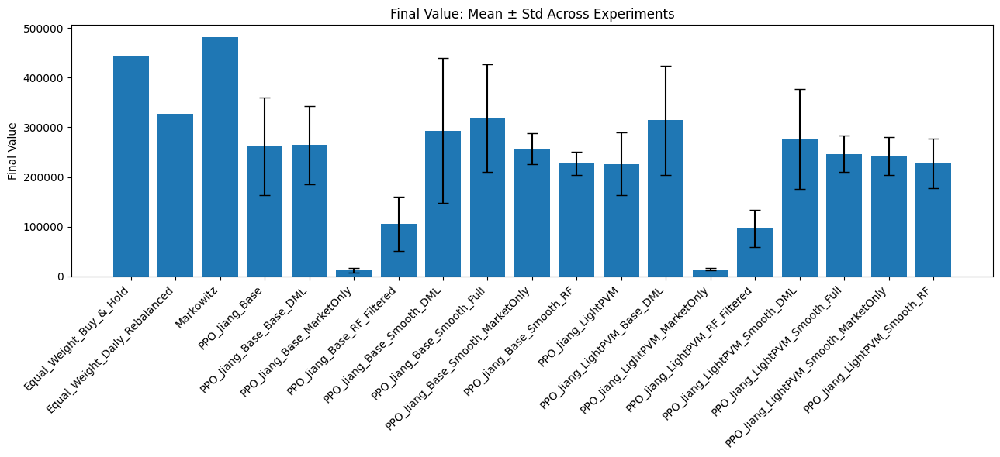

In [238]:
metric = "Final Value"

means = agg_final[metric]["mean"]
stds = agg_final[metric]["std"]

plt.figure(figsize=(13, 6))

plt.bar(
    means.index,
    means.values,
    yerr=stds.values,
    capsize=5,
)

plt.xticks(rotation=45, ha="right")

plt.ylabel(metric)
plt.title(f"{metric}: Mean ± Std Across Experiments")

plt.tight_layout()
plt.show()

In [266]:

agg_flat = agg_final.copy()
agg_flat.columns = [f"{a}_{b}" for a, b in agg_flat.columns]
agg_flat = agg_flat.reset_index()


presentation_cols = [
    "Model_Group",
    "Final Value_mean", "Final Value_std",
    "Total Return_mean", "Annualized Return_mean",
    "Volatility_mean",
    "Sharpe_mean",
    "Sortino_mean",
    "Calmar_mean",
    "Max Drawdown_mean",
    "Avg Daily Turnover_mean",
    "Approx Annual Cost Drag_mean",
]

final_results_table = agg_flat[presentation_cols].copy()

final_results_table.to_excel(
    "Aplus_final_results_table.xlsx",
    index=False
)

final_results_table

,Model_Group,Final Value_mean,Final Value_std,Total Return_mean,Annualized Return_mean,Volatility_mean,Sharpe_mean,Sortino_mean,Calmar_mean,Max Drawdown_mean,Avg Daily Turnover_mean,Approx Annual Cost Drag_mean
0,Equal_Weight_Buy_&_Hold,443345.881223,NaN,3.448174,0.337004,0.232065,1.368384,1.902162,1.338798,-0.251721,0.000772,0.000643
1,Equal_Weight_Daily_Rebalanced,327327.721862,NaN,2.273277,0.259543,0.215519,1.178807,1.703013,1.014672,-0.255790,0.013741,0.006948
2,Markowitz,481757.157955,NaN,3.817572,0.357922,0.235797,1.416358,1.972709,1.669007,-0.214452,0.030878,0.014707
3,PPO_Jiang_Base,261656.149229,97518.409590,1.616561,0.196939,0.213614,0.933366,1.361406,0.736313,-0.274844,0.077906,0.036564
4,PPO_Jiang_Base_Base_DML,264250.119445,78521.072999,1.642501,0.200722,0.195289,1.017720,1.487493,0.837442,-0.243361,0.017411,0.008524
5,PPO_Jiang_Base_MarketOnly,12353.730554,5383.025204,-0.876463,-0.340995,0.219012,-1.798791,-2.543638,-0.381136,-0.891078,1.334258,0.632711
6,PPO_Jiang_Base_RF_Filtered,105193.362852,54410.188082,0.051934,-0.011288,0.218859,0.017337,0.062167,0.033453,-0.482728,0.379674,0.174779
7,PPO_Jiang_Base_Smooth_DML,293618.599623,145297.418411,1.936186,0.214711,0.208398,0.994843,1.467646,0.837467,-0.269889,0.012883,0.006356
8,PPO_Jiang_Base_Smooth_Full,319142.233892,108258.988578,2.191422,0.244611,0.222256,1.081612,1.590095,0.928014,-0.263683,0.019601,0.010013
9,PPO_Jiang_Base_Smooth_MarketOnly,257285.711177,31187.100676,1.572857,0.200631,0.206269,0.988488,1.426322,0.770829,-0.262136,0.102344,0.048806


In [ ]:
importlib.reload(PortfolioManagement)
from PortfolioManagement import plot_metric_bar

plot_metric_bar(
    agg_final,
    metric="Final Value",
    title="Final Portfolio Wealth Across Strategies",
    ylabel="Final Portfolio Value",
    filename="fig_final_wealth.png"
)

plt.axhline(
    y=100_000,
    linestyle="--",
    linewidth=2,
    color="red",
)

    
plt.text(
    x=-0.5,
    y=initial_portfolio_value * 1.02,
    s=f"Initial Capital = ${initial_portfolio_value:,.0f}",
)


IndentationError: unexpected indent (2624786639.py, line 20)

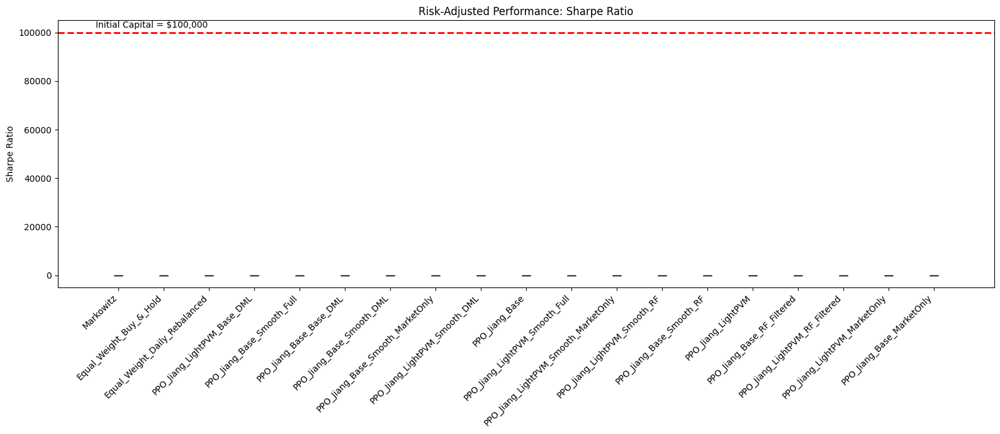

In [282]:
# Sharpe Ratio
plot_metric_bar(
    agg_final,
    metric="Sharpe",
    title="Risk-Adjusted Performance: Sharpe Ratio",
    ylabel="Sharpe Ratio",
    filename="fig_sharpe.png"
)

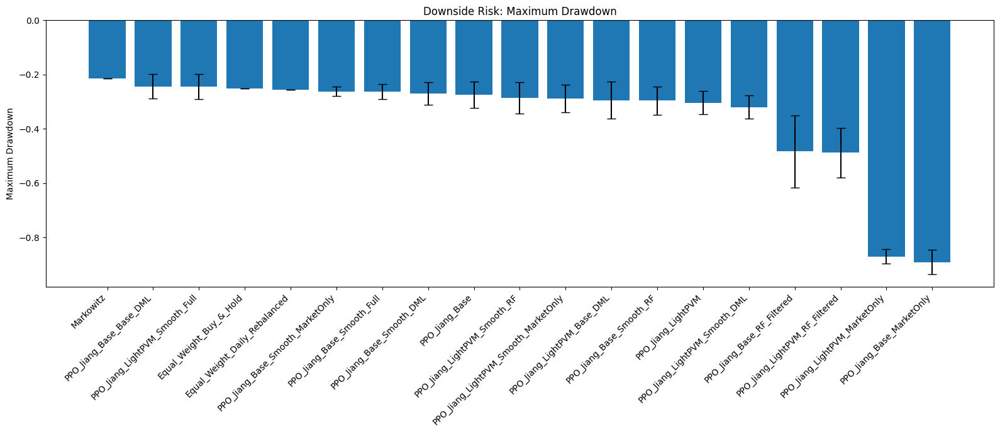

In [273]:
# Drawdown

means = agg_final["Max Drawdown"]["mean"].sort_values(ascending=False)
stds = agg_final["Max Drawdown"]["std"].reindex(means.index).fillna(0)

plt.figure(figsize=(16, 7))
plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Maximum Drawdown")
plt.title("Downside Risk: Maximum Drawdown")
plt.tight_layout()
plt.savefig("fig_max_drawdown.png", dpi=300, bbox_inches="tight")
plt.show()

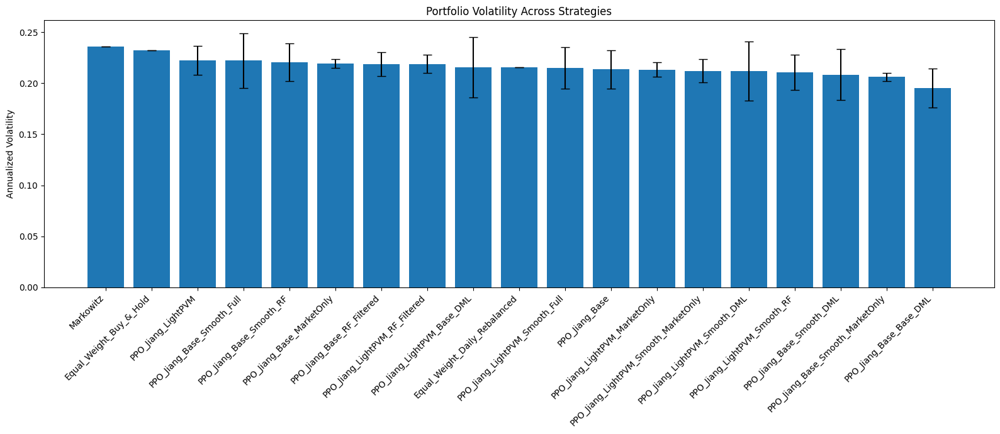

In [274]:
# Volatility

plot_metric_bar(
    agg_final,
    metric="Volatility",
    title="Portfolio Volatility Across Strategies",
    ylabel="Annualized Volatility",
    filename="fig_volatility.png"
)

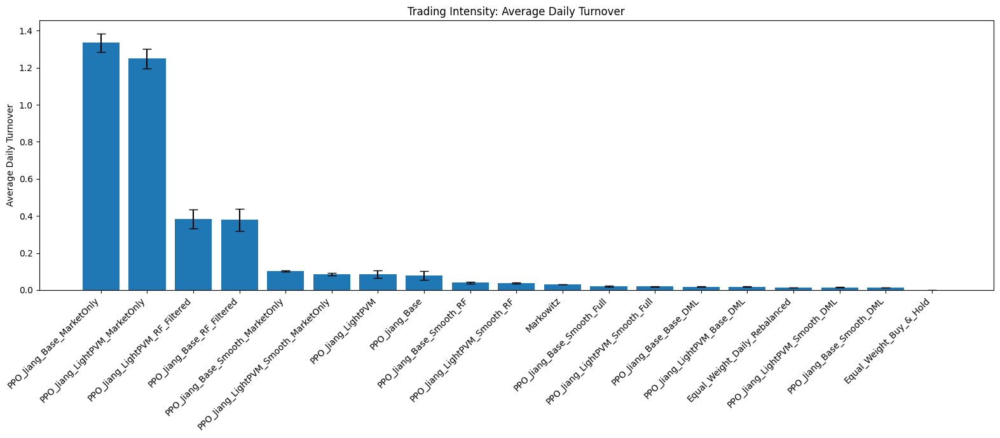

In [275]:
# Turnover

plot_metric_bar(
    agg_final,
    metric="Avg Daily Turnover",
    title="Trading Intensity: Average Daily Turnover",
    ylabel="Average Daily Turnover",
    filename="fig_turnover.png"
)

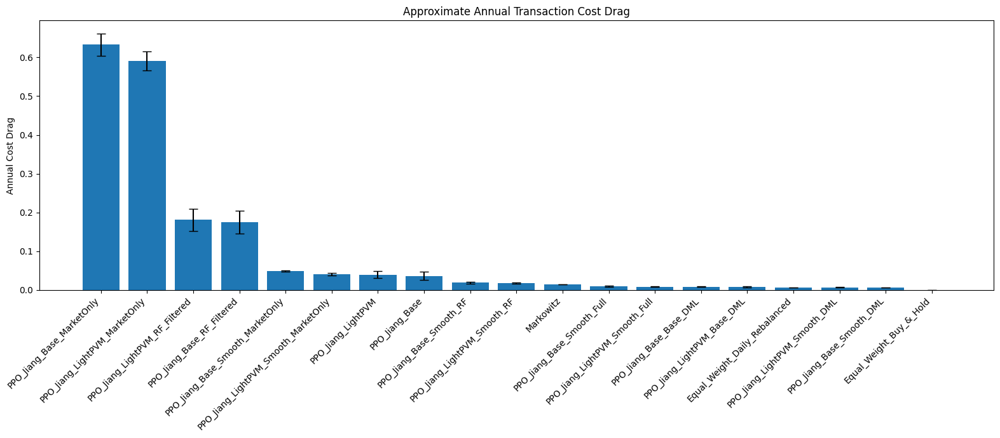

In [276]:
#  Transaction Cost Drag

plot_metric_bar(
    agg_final,
    metric="Approx Annual Cost Drag",
    title="Approximate Annual Transaction Cost Drag",
    ylabel="Annual Cost Drag",
    filename="fig_cost_drag.png"
)